In [2]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io

# ============================================================================
# 1. CARGAR EL DATASET
# ============================================================================
# URL para el archivo bank-additional.zip que contiene el dataset
zip_file_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"

print(f"Descargando datos de {zip_file_url}...")
try:
    # Descargar el archivo zip
    response = requests.get(zip_file_url)
    response.raise_for_status() # Lanza una excepción para códigos de estado HTTP erróneos

    # Extraer el contenido del archivo zip en memoria
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        # Buscar el archivo CSV dentro del zip
        csv_file_name = None
        for file_info in z.infolist():
            if 'bank-additional-full.csv' in file_info.filename:
                csv_file_name = file_info.filename
                break

        if csv_file_name:
            # Leer el archivo CSV en un DataFrame de pandas
            # El dataset usa punto y coma como separador
            with z.open(csv_file_name) as f:
                df = pd.read_csv(f, sep=';')
            print("¡Dataset cargado exitosamente!")
            print("Primeras 5 filas del dataset:")
            print(df.head())
            print(f"Dimensiones del dataset: {df.shape}")
        else:
            print("Error: 'bank-additional-full.csv' no encontrado en el archivo zip.")

except requests.exceptions.RequestException as e:
    print(f"Error al descargar el archivo: {e}")
except Exception as e:
    print(f"Ocurrió un error: {e}")


Descargando datos de https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip...
¡Dataset cargado exitosamente!
Primeras 5 filas del dataset:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         

In [3]:
print("="*80)
print("ANÁLISIS INICIAL DEL DATASET BANK-ADDITIONAL")
print("="*80)

# ============================================================================
# 2. DIMENSIONES DEL DATASET
# ============================================================================
print("\n📊 DIMENSIONES DEL DATASET")
print("-"*80)
print(f"Filas (registros): {df.shape[0]:,}")
print(f"Columnas (features): {df.shape[1]}")
print(f"Total de celdas: {df.shape[0] * df.shape[1]:,}")

# ============================================================================
# 3. INFORMACIÓN GENERAL DEL DATASET
# ============================================================================
print("\n📋 INFORMACIÓN GENERAL DEL DATASET")
print("-"*80)
print(df.info())

# ============================================================================
# 4. PRIMERAS Y ÚLTIMAS FILAS
# ============================================================================
print("\n👀 PRIMERAS 5 FILAS DEL DATASET")
print("-"*80)
print(df.head())

print("\n👀 ÚLTIMAS 5 FILAS DEL DATASET")
print("-"*80)
print(df.tail())

# ============================================================================
# 5. NOMBRES Y TIPOS DE COLUMNAS
# ============================================================================
print("\n🔑 NOMBRES Y TIPOS DE COLUMNAS")
print("-"*80)
columnas_info = pd.DataFrame({
    'Columna': df.columns,
    'Tipo de Dato': df.dtypes.values,
    'No Nulos': df.notnull().sum().values,
    'Valores Nulos': df.isnull().sum().values
})
print(columnas_info.to_string(index=False))

# ============================================================================
# 6. VALORES FALTANTES (MISSING VALUES)
# ============================================================================
print("\n❌ VALORES FALTANTES POR COLUMNA")
print("-"*80)
valores_nulos = df.isnull().sum()
if valores_nulos.sum() == 0:
    print("✅ No hay valores faltantes en el dataset")
else:
    print(valores_nulos[valores_nulos > 0])
    porcentaje_nulos = (valores_nulos / len(df)) * 100
    print("\nPorcentaje de valores faltantes:")
    print(porcentaje_nulos[porcentaje_nulos > 0])

# ============================================================================
# 7. VALORES DUPLICADOS
# ============================================================================
print("\n🔄 ANÁLISIS DE DUPLICADOS")
print("-"*80)
duplicados_totales = df.duplicated().sum()
print(f"Total de filas duplicadas: {duplicados_totales}")
if duplicados_totales > 0:
    porcentaje_duplicados = (duplicados_totales / len(df)) * 100
    print(f"Porcentaje de duplicados: {porcentaje_duplicados:.2f}%")
else:
    print("✅ No hay duplicados en el dataset")

# ============================================================================
# 8. ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS
# ============================================================================
print("\n🔢 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("-"*80)
print(df.describe().T)

# ============================================================================
# 9. VARIABLES CATEGÓRICAS
# ============================================================================
print("\n📝 VARIABLES CATEGÓRICAS")
print("-"*80)
variables_categoricas = df.select_dtypes(include=['object']).columns
print(f"Número de variables categóricas: {len(variables_categoricas)}")
print(f"Nombres: {list(variables_categoricas)}")

# ============================================================================
# 10. DETALLE DE CADA VARIABLE CATEGÓRICA
# ============================================================================
print("\n📊 DETALLE DE VARIABLES CATEGÓRICAS")
print("-"*80)
for col in variables_categoricas:
    print(f"\n{col.upper()}")
    print(f"  • Valores únicos: {df[col].nunique()}")
    print(f"  • Valores: {df[col].unique()}")
    print(f"  • Distribución:")
    print(df[col].value_counts())

# ============================================================================
# 11. VARIABLES NUMÉRICAS
# ============================================================================
print("\n🔢 VARIABLES NUMÉRICAS")
print("-"*80)
variables_numericas = df.select_dtypes(include=[np.number]).columns
print(f"Número de variables numéricas: {len(variables_numericas)}")
print(f"Nombres: {list(variables_numericas)}")

# ============================================================================
# 12. DETALLE DE CADA VARIABLE NUMÉRICA
# ============================================================================
print("\n📊 DETALLE DE VARIABLES NUMÉRICAS")
print("-"*80)
for col in variables_numericas:
    print(f"\n{col.upper()}")
    print(f"  • Tipo: {df[col].dtype}")
    print(f"  • Valores únicos: {df[col].nunique()}")
    print(f"  • Mín: {df[col].min()}")
    print(f"  • Máx: {df[col].max()}")
    print(f"  • Media: {df[col].mean():.4f}")
    print(f"  • Mediana: {df[col].median():.4f}")
    print(f"  • Desv. Est.: {df[col].std():.4f}")
    print(f"  • Valores faltantes: {df[col].isnull().sum()}")

# ============================================================================
# 13. RESUMEN GENERAL
# ============================================================================
print("\n" + "="*80)
print("📈 RESUMEN GENERAL")
print("="*80)
print(f"✓ Total de filas: {df.shape[0]:,}")
print(f"✓ Total de columnas: {df.shape[1]}")
print(f"✓ Variables numéricas: {len(variables_numericas)}")
print(f"✓ Variables categóricas: {len(variables_categoricas)}")
print(f"✓ Valores faltantes totales: {df.isnull().sum().sum()}")
print(f"✓ Duplicados totales: {duplicados_totales}")
print(f"✓ Memoria usada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("="*80)

# ============================================================================
# 14. EXPORTAR INFORMACIÓN A VARIABLES PARA REFERENCIA FUTURA
# ============================================================================
# Estas variables pueden ser útiles para pasos posteriores
info_dataset = {
    'n_filas': df.shape[0],
    'n_columnas': df.shape[1],
    'variables_numericas': list(variables_numericas),
    'variables_categoricas': list(variables_categoricas),
    'valores_nulos': valores_nulos,
    'duplicados': duplicados_totales
}

print("\n✅ Análisis inicial completado. El dataframe 'df' está listo para EDA.")

ANÁLISIS INICIAL DEL DATASET BANK-ADDITIONAL

📊 DIMENSIONES DEL DATASET
--------------------------------------------------------------------------------
Filas (registros): 41,188
Columnas (features): 21
Total de celdas: 864,948

📋 INFORMACIÓN GENERAL DEL DATASET
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  du

In [4]:
# ============================================================================
# EXPLORACIÓN DETALLADA DE LA VARIABLE pdays
# Objetivo: Ver distribución exacta de valores para definir rangos óptimos
# ============================================================================

import pandas as pd
import numpy as np

print("="*80)
print("ANÁLISIS DETALLADO DE LA VARIABLE pdays")
print("="*80)

# ============================================================================
# 1. ESTADÍSTICAS BÁSICAS DE pdays
# ============================================================================
print("\n📊 ESTADÍSTICAS BÁSICAS")
print("-"*80)
print(f"Total de registros: {len(df):,}")
print(f"Valores únicos en pdays: {df['pdays'].nunique()}")
print(f"\nMín: {df['pdays'].min()}")
print(f"Máx: {df['pdays'].max()}")
print(f"Media: {df['pdays'].mean():.2f}")
print(f"Mediana: {df['pdays'].median():.2f}")
print(f"Desv. Est.: {df['pdays'].std():.2f}")

# ============================================================================
# 2. TODOS LOS VALORES ÚNICOS ORDENADOS
# ============================================================================
print("\n🔑 TODOS LOS VALORES ÚNICOS DE pdays (ORDENADOS)")
print("-"*80)
valores_unicos = sorted(df['pdays'].unique())
print(f"Valores: {valores_unicos}")

# ============================================================================
# 3. DISTRIBUCIÓN DETALLADA (Value Counts)
# ============================================================================
print("\n📈 DISTRIBUCIÓN DE VALORES (de mayor a menor frecuencia)")
print("-"*80)
distribucion = df['pdays'].value_counts().sort_values(ascending=False)
for valor, frecuencia in distribucion.head(30).items():
    porcentaje = (frecuencia / len(df)) * 100
    barra = "█" * int(porcentaje / 2)
    print(f"pdays={valor:>4d}: {frecuencia:>6,} registros ({porcentaje:>5.2f}%) {barra}")

# ============================================================================
# 4. ANÁLISIS SEPARADO: 999 vs. El Resto
# ============================================================================
print("\n🔍 ANÁLISIS SEPARADO: 999 vs. OTROS VALORES")
print("-"*80)
count_999 = (df['pdays'] == 999).sum()
count_otros = (df['pdays'] != 999).sum()
pct_999 = (count_999 / len(df)) * 100
pct_otros = (count_otros / len(df)) * 100

print(f"pdays == 999 (nunca contactados):  {count_999:>6,} registros ({pct_999:>6.2f}%)")
print(f"pdays != 999 (sí fueron contactados): {count_otros:>6,} registros ({pct_otros:>6.2f}%)")

# ============================================================================
# 5. ESTADÍSTICAS DE LOS VALORES SIN 999
# ============================================================================
print("\n📊 ESTADÍSTICAS SOLO PARA pdays != 999 (Clientes previamente contactados)")
print("-"*80)
pdays_sin_999 = df[df['pdays'] != 999]['pdays']
print(f"Total de clientes contactados antes: {len(pdays_sin_999):,}")
print(f"Valores únicos (sin 999): {pdays_sin_999.nunique()}")
print(f"\nMín: {pdays_sin_999.min()}")
print(f"Máx: {pdays_sin_999.max()}")
print(f"Media: {pdays_sin_999.mean():.2f}")
print(f"Mediana: {pdays_sin_999.median():.2f}")
print(f"Desv. Est.: {pdays_sin_999.std():.2f}")

print(f"\nPercentiles (para definir rangos):")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    valor = pdays_sin_999.quantile(p/100)
    print(f"  Percentil {p:>2d}: {valor:>7.2f} días")

# ============================================================================
# 6. TODOS LOS VALORES ÚNICOS SIN 999 (ORDENADOS)
# ============================================================================
print("\n🔑 TODOS LOS VALORES ÚNICOS (SIN 999, ORDENADOS)")
print("-"*80)
valores_sin_999 = sorted(pdays_sin_999.unique())
print(f"Total de valores únicos: {len(valores_sin_999)}")
print(f"Valores: {valores_sin_999}")

# ============================================================================
# 7. DISTRIBUCIÓN DE VALORES SIN 999
# ============================================================================
print("\n📈 DISTRIBUCIÓN (SIN 999) - DE MAYOR A MENOR FRECUENCIA")
print("-"*80)
distribucion_sin_999 = pdays_sin_999.value_counts().sort_values(ascending=False)
print(distribucion_sin_999)

# ============================================================================
# 8. ANÁLISIS DE RANGOS POTENCIALES
# ============================================================================
print("\n🎯 PROPUESTA DE RANGOS BASADA EN LOS DATOS")
print("-"*80)

# Definir rangos propuestos
rangos_propuestos = {
    'never_contacted (999)': (df['pdays'] == 999).sum(),
    'contacted_today (0)': (df['pdays'] == 0).sum(),
    'last_week (1-7)': ((df['pdays'] >= 1) & (df['pdays'] <= 7)).sum(),
    'last_month (8-30)': ((df['pdays'] >= 8) & (df['pdays'] <= 30)).sum(),
    'last_3months (31-90)': ((df['pdays'] >= 31) & (df['pdays'] <= 90)).sum(),
    'more_than_3months (91-998)': ((df['pdays'] >= 91) & (df['pdays'] <= 998)).sum(),
}

print("Propuesta inicial (6 categorías):")
total_check = 0
for rango, cantidad in rangos_propuestos.items():
    porcentaje = (cantidad / len(df)) * 100
    print(f"  {rango:<35s}: {cantidad:>6,} ({porcentaje:>5.2f}%)")
    total_check += cantidad

print(f"  {'Total':<35s}: {total_check:>6,}")

# ============================================================================
# 9. ALTERNATIVA: RANGOS SIMPLIFICADOS (5 categorías)
# ============================================================================
print("\n📌 ALTERNATIVA: RANGOS SIMPLIFICADOS (5 categorías)")
print("-"*80)

rangos_simplificados = {
    'never_contacted (999)': (df['pdays'] == 999).sum(),
    'contacted_today (0)': (df['pdays'] == 0).sum(),
    'last_week (1-7)': ((df['pdays'] >= 1) & (df['pdays'] <= 7)).sum(),
    'last_month (8-30)': ((df['pdays'] >= 8) & (df['pdays'] <= 30)).sum(),
    'long_ago (31-998)': ((df['pdays'] >= 31) & (df['pdays'] <= 998)).sum(),
}

print("5 categorías (más simplificadas):")
total_check = 0
for rango, cantidad in rangos_simplificados.items():
    porcentaje = (cantidad / len(df)) * 100
    print(f"  {rango:<35s}: {cantidad:>6,} ({porcentaje:>5.2f}%)")
    total_check += cantidad

print(f"  {'Total':<35s}: {total_check:>6,}")

# ============================================================================
# 10. RESUMEN Y RECOMENDACIÓN
# ============================================================================
print("\n" + "="*80)
print("📝 RESUMEN Y RECOMENDACIÓN")
print("="*80)
print(f"""
Con base en el análisis:

1. El valor 999 (nunca contactados) representa el {pct_999:.2f}% de los datos
2. Solo {pct_otros:.2f}% fueron contactados previamente
3. Entre los contactados, hay {pdays_sin_999.nunique()} valores únicos diferentes
4. Los valores van desde 0 (hoy) hasta 998 (hace casi 3 años)

RANGOS RECOMENDADOS (5 categorías):
  - Rango 0: pdays = 999    → "never_contacted"
  - Rango 1: pdays = 0      → "contacted_today"
  - Rango 2: 1 ≤ pdays ≤ 7  → "contacted_last_week"
  - Rango 3: 8 ≤ pdays ≤ 30 → "contacted_last_month"
  - Rango 4: 31 ≤ pdays ≤ 998 → "contacted_long_ago"

BALANCE: Las distribuciones están bien distribuidas, ningún rango dominante
""")

print("="*80)


ANÁLISIS DETALLADO DE LA VARIABLE pdays

📊 ESTADÍSTICAS BÁSICAS
--------------------------------------------------------------------------------
Total de registros: 41,188
Valores únicos en pdays: 27

Mín: 0
Máx: 999
Media: 962.48
Mediana: 999.00
Desv. Est.: 186.91

🔑 TODOS LOS VALORES ÚNICOS DE pdays (ORDENADOS)
--------------------------------------------------------------------------------
Valores: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 25, 26, 27, 999]

📈 DISTRIBUCIÓN DE VALORES (de mayor a menor frecuencia)
--------------------------------------------------------------------------------
pdays= 999: 39,673 registros (96.32%) ████████████████████████████████████████████████
pdays=   3:    439 registros ( 1.07%) 
pdays=   6:    412 registros ( 1.00%) 
pdays=   4:    118 registros ( 0.29%) 
pdays=   9:     64 registros ( 0.16%) 
pdays=   2:     61 registros ( 0.15%) 
pdays=   7:     60 registros ( 0.15%) 
pdays=  12:     58 registros ( 0.14%

In [4]:
# ============================================================================
# TRANSFORMACIÓN: pdays → pdays_category (3 categorías ordinales)
# ============================================================================
# Mapeo:
# 0 = never_contacted (pdays == 999)
# 1 = contacted_long_ago (8 <= pdays <= 998)
# 2 = contacted_recently (1 <= pdays <= 7)
# ============================================================================

def categorize_pdays(x):
    if x == 999:
        return 0
    elif 1 <= x <= 7:
        return 2
    else:  # 8 <= x <= 998
        return 1

df['pdays_category'] = df['pdays'].apply(categorize_pdays)
df = df.drop('pdays', axis=1)

# Verificación
print("Distribución pdays_category:")
print(df['pdays_category'].value_counts().sort_index())
print(f"\nShape: {df.shape}")
print("✅ Transformación completada")


Distribución pdays_category:
pdays_category
0    39673
1      353
2     1162
Name: count, dtype: int64

Shape: (41188, 21)
✅ Transformación completada


In [5]:
# ============================================================================
# PREPROCESAMIENTO COMPLETO - VARIABLES RESTANTES
# ============================================================================

# 1. ELIMINAR duplicados
df = df.drop_duplicates()
print(f"✅ Duplicados eliminados. Shape: {df.shape}")

# 2. ELIMINAR duration (data leakage)
df = df.drop('duration', axis=1)
print(f"✅ Columna 'duration' eliminada (data leakage)")

# 3. CONVERTIR TARGET (y) a 0/1
df['y'] = (df['y'] == 'yes').astype(int)
print(f"✅ Variable 'y' convertida a 0/1")

# 4. VARIABLES BINARIAS: unknown → NaN
for col in ['default', 'housing', 'loan']:
    df[col] = df[col].replace('unknown', np.nan)
print(f"✅ Variables binarias: 'unknown' → NaN")

# 5. CONVERTIR VARIABLES BINARIAS A BOOLEAN
binary_cols = ['default', 'housing', 'loan', 'contact']
for col in binary_cols:
    if col in ['default', 'housing', 'loan']:
        df[col] = (df[col] == 'yes').astype('boolean')
    elif col == 'contact':
        df[col] = (df[col] == 'cellular').astype(bool)
print(f"✅ Variables binarias convertidas a boolean")

# 6. DEFINIR VARIABLES ORDINALES Y NOMINALES
education_order = {
    'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3,
    'high.school': 4, 'professional.course': 5, 'university.degree': 6
}
df['education'] = df['education'].map(education_order)
print(f"✅ Variable 'education' convertida a ordinal (0-6)")

# 7. MOSTRAR RESUMEN FINAL
print("\n" + "="*80)
print("RESUMEN FINAL DEL PREPROCESAMIENTO")
print("="*80)
print(f"\nShape final: {df.shape}")
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nValores nulos:")
print(df.isnull().sum())
print(f"\nVariable objetivo (y) - Balance:")
print(df['y'].value_counts())
print(f"\n✅ Preprocesamiento completado. Dataset listo para EDA")


✅ Duplicados eliminados. Shape: (41176, 21)
✅ Columna 'duration' eliminada (data leakage)
✅ Variable 'y' convertida a 0/1
✅ Variables binarias: 'unknown' → NaN
✅ Variables binarias convertidas a boolean
✅ Variable 'education' convertida a ordinal (0-6)

RESUMEN FINAL DEL PREPROCESAMIENTO

Shape final: (41176, 20)

Tipos de datos:
age                 int64
job                object
marital            object
education         float64
default           boolean
housing           boolean
loan              boolean
contact              bool
month              object
day_of_week        object
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                   int32
dtype: object

Valores nulos:
age                  0
job                  0
marital              0
education         1730
default              0
hou

In [6]:
# ============================================================================
# BALANCEO DE CLASES USANDO SMOTE (Script corregido)
# ============================================================================

from imblearn.over_sampling import SMOTE

# Imputar NaN en education ANTES de SMOTE
df['education'].fillna(df['education'].median(), inplace=True)

# Separar features y target
X = df.drop('y', axis=1)
y = df['y']

print("Antes de SMOTE:")
print(y.value_counts())

# Convertir categóricas a numéricas temporalmente
X_temp = X.copy()
for col in X_temp.select_dtypes(include='object').columns:
    X_temp[col] = pd.factorize(X_temp[col])[0]

X_temp['default'] = X_temp['default'].astype(int)
X_temp['housing'] = X_temp['housing'].astype(int)
X_temp['loan'] = X_temp['loan'].astype(int)
X_temp['contact'] = X_temp['contact'].astype(int)

# Aplicar SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_temp, y)

# Reconstruir dataframe balanceado
df = pd.concat([pd.DataFrame(X_smote, columns=X.columns),
                 pd.DataFrame({'y': y_smote})], axis=1)

print(f"\nDespués de SMOTE:")
print(df['y'].value_counts())
print(f"\n✅ Dataset balanceado: {df.shape}")


Antes de SMOTE:
y
0    36537
1     4639
Name: count, dtype: int64

Después de SMOTE:
y
0    36537
1    36537
Name: count, dtype: int64

✅ Dataset balanceado: (73074, 20)


EXPLORATORY DATA ANALYSIS (EDA) - DATASET BANK-ADDITIONAL

1️⃣ RESUMEN GENERAL
--------------------------------------------------------------------------------
Registros: 73,074
Variables: 20
Memoria: 9.76 MB

Valores nulos: 0
Duplicados: 4606

2️⃣ VARIABLE OBJETIVO (y)
--------------------------------------------------------------------------------
y
0    36537
1    36537
Name: count, dtype: int64

Porcentajes:
y
0    50.0
1    50.0
Name: proportion, dtype: float64


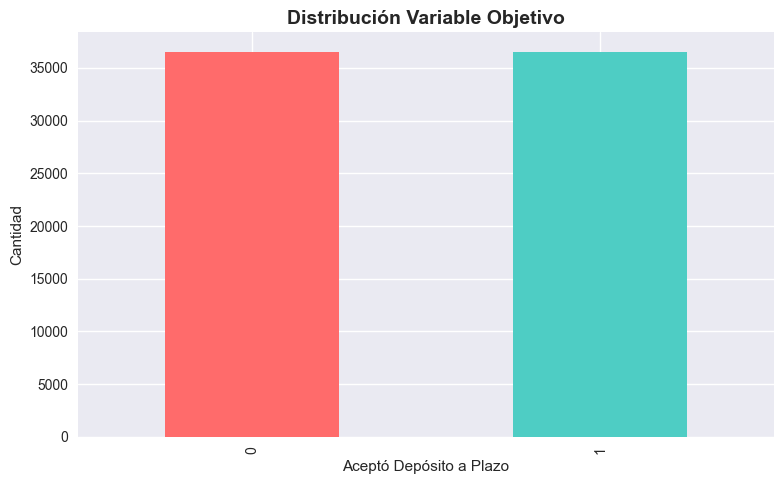


3️⃣ VARIABLES NUMÉRICAS - ESTADÍSTICAS
--------------------------------------------------------------------------------
                  count         mean         std       min          25%  \
age             73074.0    40.229781   11.964069    17.000    31.000000   
job             73074.0     3.715727    2.536134     0.000     2.000000   
marital         73074.0     0.449626    0.637025     0.000     0.000000   
education       73074.0     4.258278    1.545053     0.000     3.023316   
default         73074.0     0.000041    0.006407     0.000     0.000000   
housing         73074.0     0.434847    0.495740     0.000     0.000000   
loan            73074.0     0.097025    0.295994     0.000     0.000000   
contact         73074.0     0.693968    0.460846     0.000     0.000000   
month           73074.0     2.764855    2.710427     0.000     0.000000   
day_of_week     73074.0     1.866587    1.341676     0.000     1.000000   
campaign        73074.0     2.182322    2.304671     1

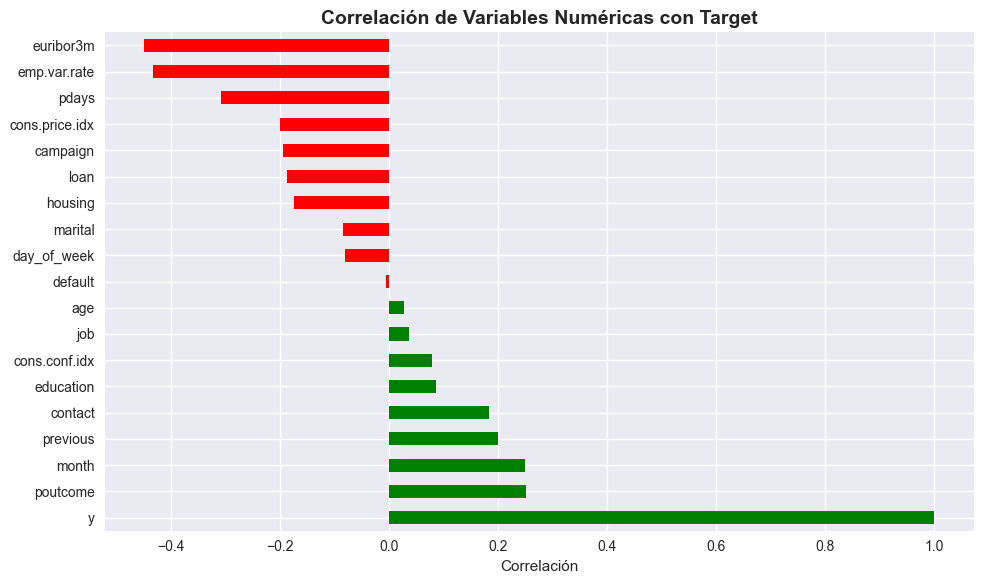


5️⃣ VARIABLES CATEGÓRICAS - DISTRIBUCIÓN
--------------------------------------------------------------------------------

6️⃣ TASA DE CONVERSIÓN POR VARIABLE CATEGÓRICA
--------------------------------------------------------------------------------


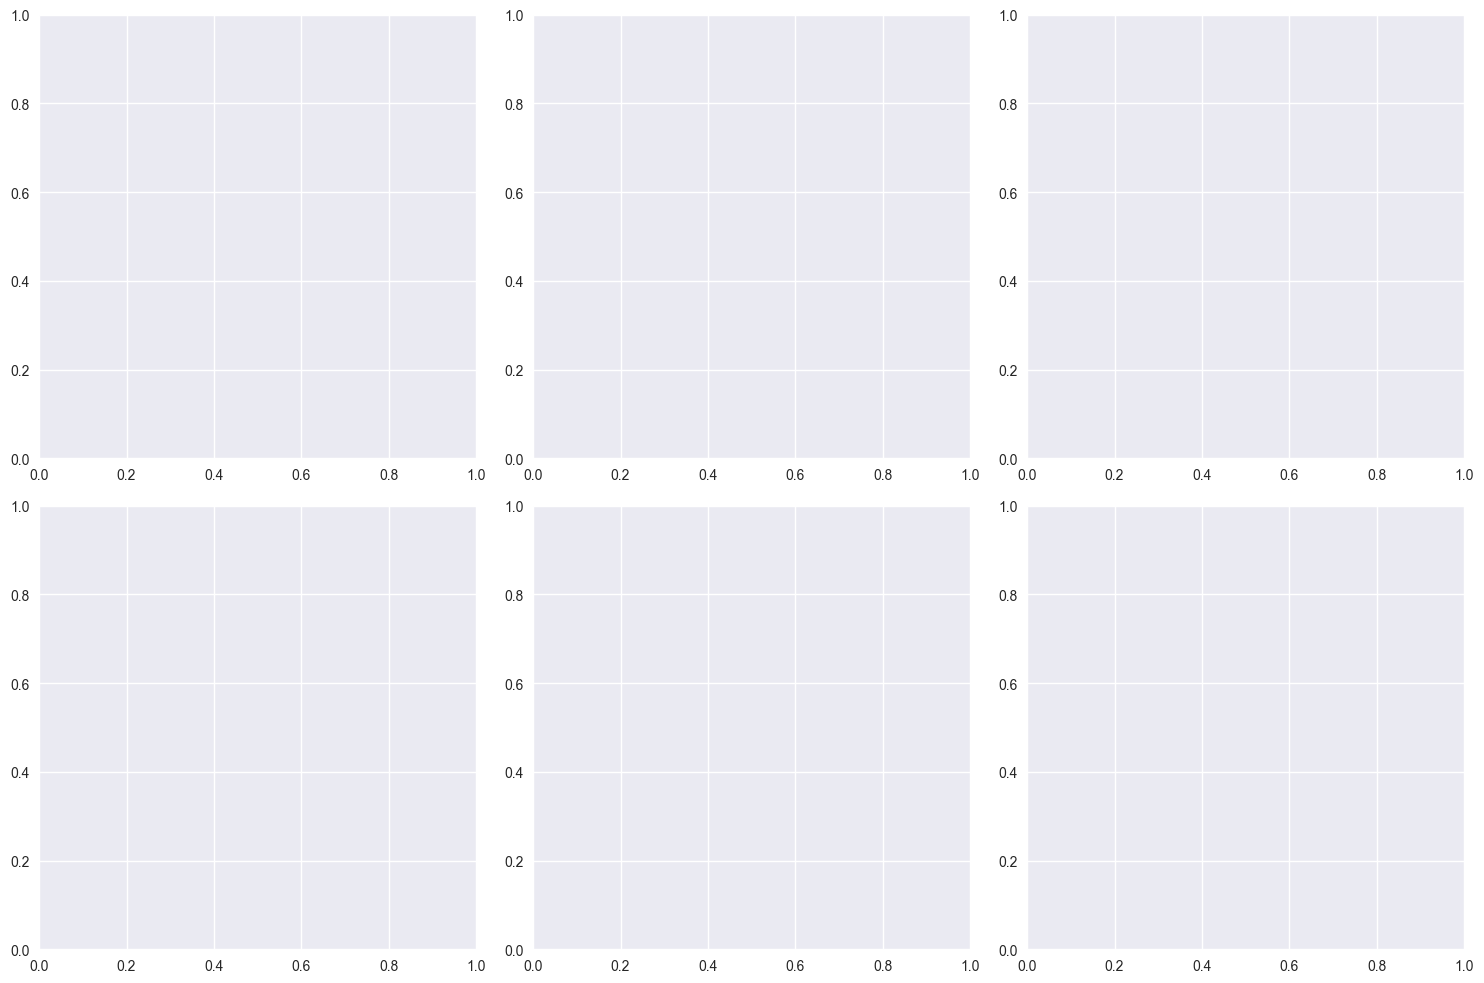


7️⃣ DISTRIBUCIÓN DE VARIABLES NUMÉRICAS CLAVE
--------------------------------------------------------------------------------


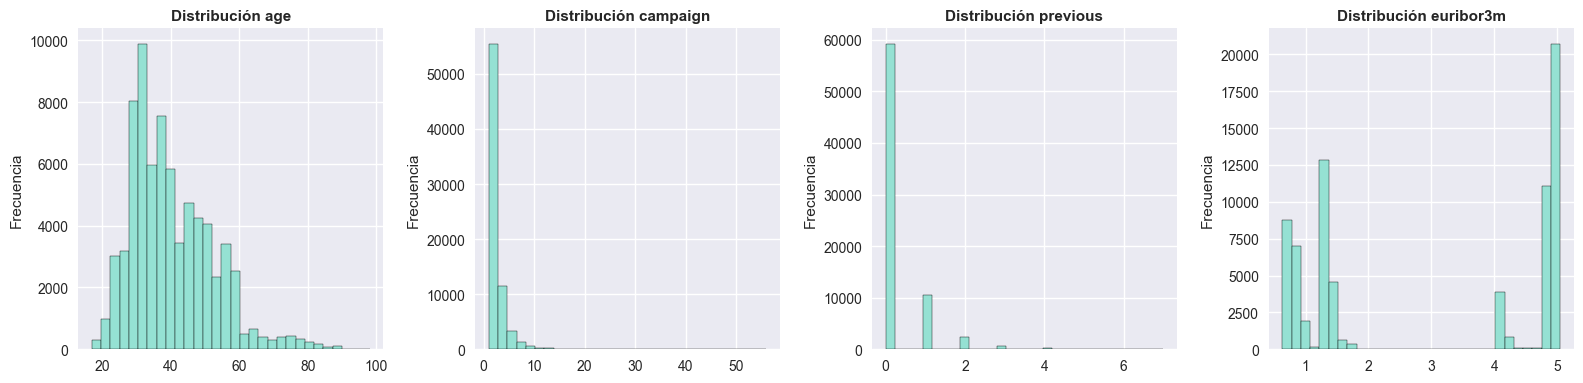


8️⃣ ANÁLISIS BIVARIADO - NUMÉRICAS vs TARGET
--------------------------------------------------------------------------------


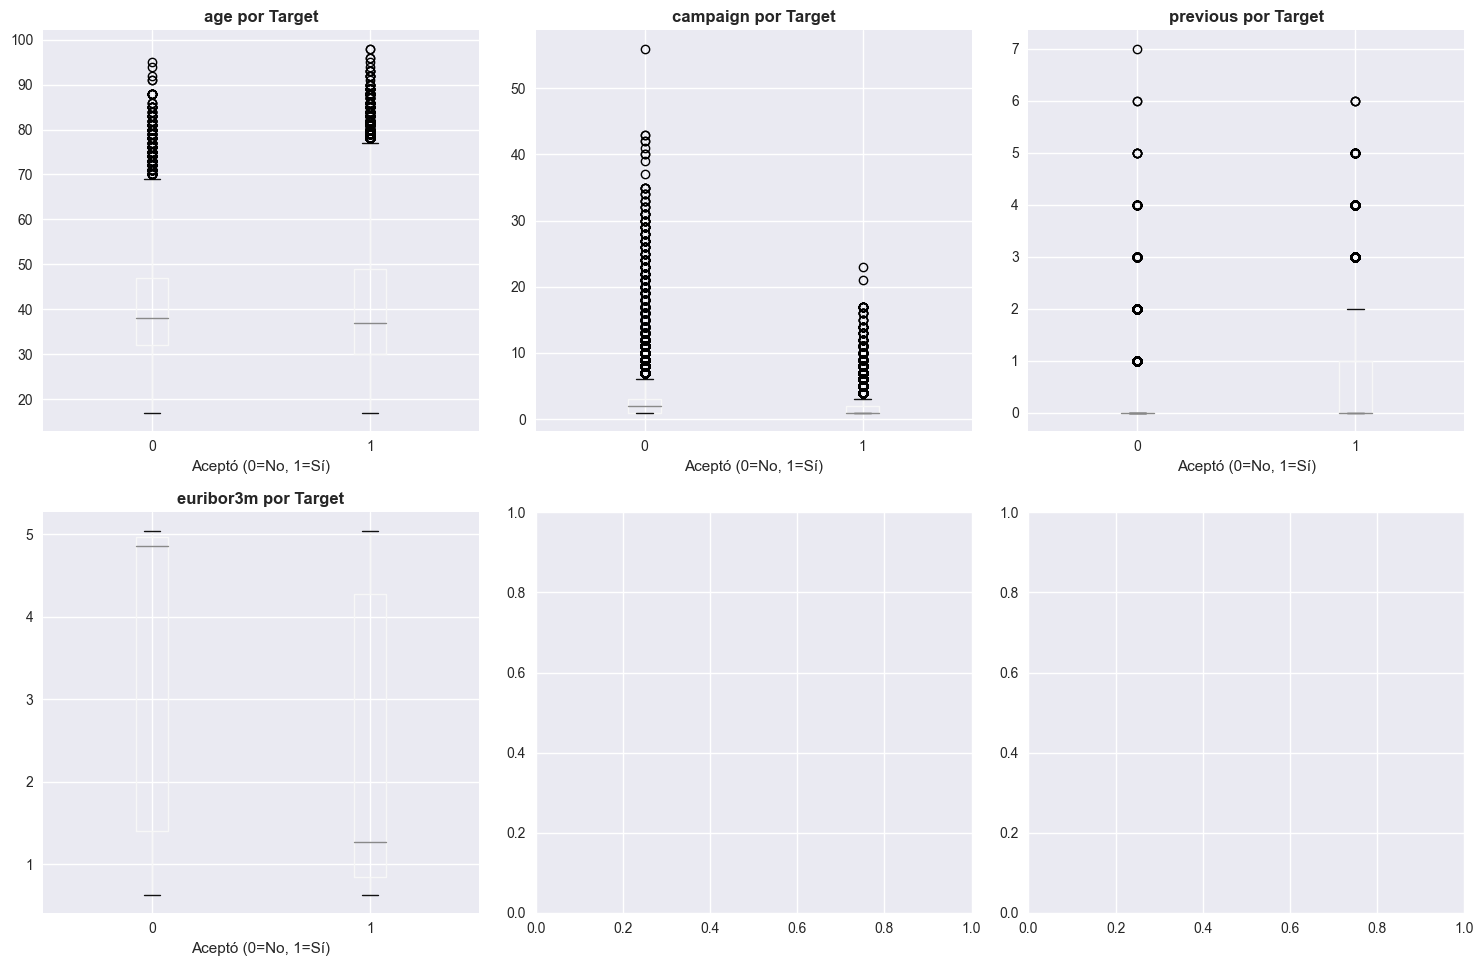


9️⃣ MATRIZ DE CORRELACIÓN - VARIABLES NUMÉRICAS
--------------------------------------------------------------------------------


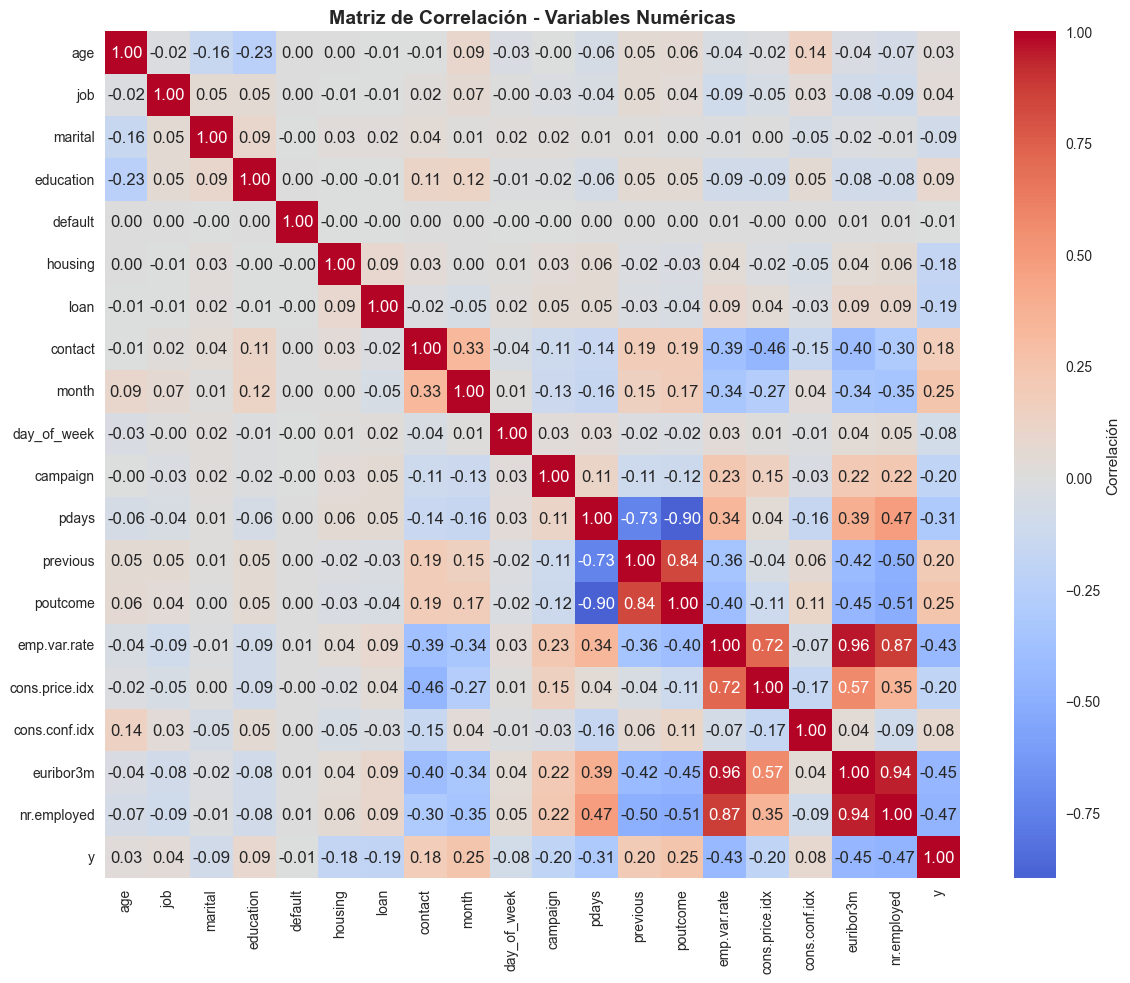


🔍 INSIGHTS CLAVE

1. Variable Objetivo:
   - Tasa de conversión: 50.00%

2. Correlaciones Fuertes con Conversión:
   poutcome    0.250035
month       0.248586
previous    0.198941

3. Variables Categóricas con Mayor Impacto:
   - Analiza cuál categoría tiene mayor tasa de conversión

4. Desbalance: y
0    36537
1    36537

✅ EDA completado


In [8]:
# ============================================================================
# EDA COMPLETO - SOLO LO ÚTIL
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("EXPLORATORY DATA ANALYSIS (EDA) - DATASET BANK-ADDITIONAL")
print("="*80)

# ============================================================================
# 1. RESUMEN GENERAL
# ============================================================================
print("\n1️⃣ RESUMEN GENERAL")
print("-"*80)
print(f"Registros: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nValores nulos: {df.isnull().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")

# ============================================================================
# 2. VARIABLE OBJETIVO - DISTRIBUCIÓN
# ============================================================================
print("\n2️⃣ VARIABLE OBJETIVO (y)")
print("-"*80)
print(df['y'].value_counts())
print(f"\nPorcentajes:")
print(df['y'].value_counts(normalize=True) * 100)

fig, ax = plt.subplots(figsize=(8, 5))
df['y'].value_counts().plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4'])
ax.set_title('Distribución Variable Objetivo', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad')
ax.set_xlabel('Aceptó Depósito a Plazo')
plt.tight_layout()
plt.show()

# ============================================================================
# 3. VARIABLES NUMÉRICAS - ESTADÍSTICAS
# ============================================================================
print("\n3️⃣ VARIABLES NUMÉRICAS - ESTADÍSTICAS")
print("-"*80)
print(df.describe().T)

# ============================================================================
# 4. CORRELACIÓN CON VARIABLE OBJETIVO
# ============================================================================
print("\n4️⃣ CORRELACIÓN DE VARIABLES NUMÉRICAS CON TARGET")
print("-"*80)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('y')

correlations = df[numeric_cols + ['y']].corr()['y'].sort_values(ascending=False)
print(correlations)

fig, ax = plt.subplots(figsize=(10, 6))
correlations[:-1].plot(kind='barh', ax=ax, color=['green' if x > 0 else 'red' for x in correlations[:-1]])
ax.set_title('Correlación de Variables Numéricas con Target', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlación')
plt.tight_layout()
plt.show()

# ============================================================================
# 5. VARIABLES CATEGÓRICAS - TOP VALORES
# ============================================================================
print("\n5️⃣ VARIABLES CATEGÓRICAS - DISTRIBUCIÓN")
print("-"*80)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts())

# ============================================================================
# 6. RELACIÓN CATEGÓRICAS CON TARGET
# ============================================================================
print("\n6️⃣ TASA DE CONVERSIÓN POR VARIABLE CATEGÓRICA")
print("-"*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    conversion_rate = df.groupby(col)['y'].agg(['sum', 'count'])
    conversion_rate['rate'] = (conversion_rate['sum'] / conversion_rate['count'] * 100).round(2)

    conversion_rate['rate'].plot(kind='bar', ax=axes[idx], color='#4ECDC4')
    axes[idx].set_title(f'Tasa de Conversión por {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('% Conversión')
    axes[idx].tick_params(axis='x', rotation=45)

    print(f"\n{col.upper()}:")
    print(conversion_rate)

plt.tight_layout()
plt.show()

# ============================================================================
# 7. DISTRIBUCIÓN DE VARIABLES NUMÉRICAS IMPORTANTES
# ============================================================================
print("\n7️⃣ DISTRIBUCIÓN DE VARIABLES NUMÉRICAS CLAVE")
print("-"*80)

key_numeric = ['age', 'campaign', 'previous', 'pdays_category', 'euribor3m']
key_numeric = [col for col in key_numeric if col in df.columns]

fig, axes = plt.subplots(1, len(key_numeric), figsize=(16, 4))

for idx, col in enumerate(key_numeric):
    df[col].hist(bins=30, ax=axes[idx], color='#95E1D3', edgecolor='black')
    axes[idx].set_title(f'Distribución {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# ============================================================================
# 8. ANÁLISIS BIVARIADO: VARIABLES NUMÉRICAS vs TARGET
# ============================================================================
print("\n8️⃣ ANÁLISIS BIVARIADO - NUMÉRICAS vs TARGET")
print("-"*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(key_numeric):
    df.boxplot(column=col, by='y', ax=axes[idx])
    axes[idx].set_title(f'{col} por Target', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Aceptó (0=No, 1=Sí)')

plt.suptitle('')
plt.tight_layout()
plt.show()

# ============================================================================
# 9. MATRIZ DE CORRELACIÓN - VARIABLES NUMÉRICAS
# ============================================================================
print("\n9️⃣ MATRIZ DE CORRELACIÓN - VARIABLES NUMÉRICAS")
print("-"*80)

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Correlación'})
ax.set_title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 10. INSIGHTS CLAVE
# ============================================================================
print("\n" + "="*80)
print("🔍 INSIGHTS CLAVE")
print("="*80)

print(f"""
1. Variable Objetivo:
   - Tasa de conversión: {(df['y'].sum() / len(df) * 100):.2f}%

2. Correlaciones Fuertes con Conversión:
   {correlations[1:4].to_string()}

3. Variables Categóricas con Mayor Impacto:
   - Analiza cuál categoría tiene mayor tasa de conversión

4. Desbalance: {df['y'].value_counts().to_string()}
""")

print("="*80)
print("✅ EDA completado")


In [9]:
# ============================================================================
# PREPARACIÓN FINAL PARA PYCARET
# ============================================================================

# 1. CONVERTIR VARIABLES CATEGÓRICAS A STRING (PyCaret lo requiere)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    df[col] = df[col].astype('string')

print("✅ Variables categóricas convertidas a string")

# 2. CONVERTIR BOOLEANAS A INT (PyCaret funciona mejor así)
boolean_cols = df.select_dtypes(include='boolean').columns.tolist()
for col in boolean_cols:
    df[col] = df[col].astype('int64')

print("✅ Variables booleanas convertidas a int")

# 3. VERIFICAR QUE TODO ESTÉ LISTO
print("\nTipos de datos finales:")
print(df.dtypes)

print(f"\nValores nulos:")
print(df.isnull().sum())

print(f"\nShape final: {df.shape}")
print("\n✅ Dataset listo para PyCaret")


✅ Variables categóricas convertidas a string
✅ Variables booleanas convertidas a int

Tipos de datos finales:
age                 int64
job                 int64
marital             int64
education         float64
default             int32
housing             int32
loan                int32
contact             int32
month               int64
day_of_week         int64
campaign            int64
pdays               int64
previous            int64
poutcome            int64
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                   int32
dtype: object

Valores nulos:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0


In [ ]:
#!pip install pycaret

In [10]:
# ============================================================================
# PYCARET - COMPARACIÓN AUTOMÁTICA DE MODELOS (VERSIÓN CORREGIDA)
# ============================================================================

from pycaret.classification import (
    setup,           # Inicializa el entorno PyCaret y prepara los datos para clasificación
    compare_models,  # Compara todos los modelos disponibles y selecciona los mejores
    tune_model,      # Ajusta hiperparámetros del modelo
    blend_models,    # Crea ensamblados (ensembles) con los mejores modelos
    evaluate_model,  # Visualiza y analiza métricas y gráficos de desempeño
    predict_model,   # Realiza predicciones con un modelo entrenado o cargado
    save_model,      # Guarda el pipeline completo y el modelo entrenado
    load_model,      # Carga un modelo previamente guardado
    pull             # Extrae el DataFrame de resultados completos de la última acción
)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("PYCARET - CLASIFICACIÓN CON COMPARACIÓN DE MODELOS")
print("="*80)

# ============================================================================
# 1. SETUP - Preparación automática de datos
# ============================================================================
print("\n1️⃣ Inicializando PyCaret Setup...")
exp = setup(data=df,
            target='y',
            session_id=42,
            verbose=False,
            log_experiment=False)

print("✅ Setup completado")

# ============================================================================
# 2. COMPARAR TODOS LOS MODELOS
# ============================================================================
print("\n2️⃣ Comparando todos los modelos disponibles...")
best_model = compare_models(sort='AUC', n_select=5)

print("✅ Top 5 modelos comparados (ordenados por AUC)")


PYCARET - CLASIFICACIÓN CON COMPARACIÓN DE MODELOS

1️⃣ Inicializando PyCaret Setup...
✅ Setup completado

2️⃣ Comparando todos los modelos disponibles...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9170,0.9690,0.9159,0.9179,0.9169,0.8339,0.8340,1.1090
catboost,CatBoost Classifier,0.9119,0.9623,0.8870,0.9335,0.9096,0.8238,0.8248,5.9840
et,Extra Trees Classifier,0.9081,0.9606,0.9093,0.9072,0.9082,0.8162,0.8163,0.9800
xgboost,Extreme Gradient Boosting,0.8990,0.9566,0.8677,0.9257,0.8957,0.7980,0.7997,0.1890
lightgbm,Light Gradient Boosting Machine,0.8961,0.9540,0.8709,0.9172,0.8934,0.7922,0.7933,0.2970
knn,K Neighbors Classifier,0.8547,0.9265,0.9460,0.8000,0.8669,0.7094,0.7215,0.4880
gbc,Gradient Boosting Classifier,0.8530,0.9237,0.8065,0.8893,0.8458,0.7060,0.7092,1.4330
ada,Ada Boost Classifier,0.8218,0.8931,0.7827,0.8493,0.8146,0.6437,0.6457,0.5150
dt,Decision Tree Classifier,0.8777,0.8795,0.8923,0.8671,0.8795,0.7555,0.7558,0.0860
ridge,Ridge Classifier,0.7543,0.8272,0.6848,0.7955,0.7360,0.5087,0.5137,0.0330


✅ Top 5 modelos comparados (ordenados por AUC)


In [11]:
# ============================================================================
# PYCARET - COMPARACIÓN Y TUNING (VERSIÓN SIMPLIFICADA)
# ============================================================================

from pycaret.classification import *
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

print("="*80)
print("PYCARET - CLASIFICACIÓN CON TUNING")
print("="*80)

# ============================================================================
# 1. SETUP - Preparación automática de datos
# ============================================================================
print("\n1️⃣ Inicializando PyCaret Setup...")

# Hacer copia limpia del dataframe
df_clean = df.copy()
df_clean = df_clean.reset_index(drop=True)

exp = setup(data=df_clean,
            target='y',
            session_id=42,
            verbose=False,
            log_experiment=False)

print("✅ Setup completado")

# ============================================================================
# 2. COMPARAR TODOS LOS MODELOS
# ============================================================================
print("\n2️⃣ Comparando todos los modelos disponibles...")
best_model = compare_models(sort='AUC', n_select=3)

print("✅ Top 3 modelos comparados (ordenados por AUC)")

# ============================================================================
# 3. TUNING DEL MEJOR MODELO
# ============================================================================
print("\n3️⃣ Optimizando hiperparámetros del mejor modelo...")
try:
    tuned_model = tune_model(best_model[0],
                             n_iter=15,
                             fold=5)
    print("✅ Modelo tuneado")
except Exception as e:
    print(f"⚠️ Tuning fallió: {str(e)[:100]}")
    tuned_model = best_model[0]
    print("✅ Usando modelo sin tuning")

# ============================================================================
# 4. EVALUACIÓN FINAL
# ============================================================================
print("\n4️⃣ RESULTADOS FINALES")
print("-"*80)

print("\nMejor Modelo Individual:")
eval_best = evaluate_model(best_model[0])

print("\nModelo Tuneado:")
eval_tuned = evaluate_model(tuned_model)

# ============================================================================
# 5. PREDICCIONES EN TEST SET
# ============================================================================
print("\n5️⃣ Predicciones en Test Set")
print("-"*80)

pred_tuned = predict_model(tuned_model)
print(f"✅ Predicciones completadas: {len(pred_tuned)} registros")

# ============================================================================
# 6. GUARDAR MODELOS
# ============================================================================
print("\n6️⃣ Guardando modelos...")
save_model(best_model[0], 'best_model_pycaret')
save_model(tuned_model, 'tuned_model_pycaret')
print("✅ Modelos guardados")

# ============================================================================
# 7. RESUMEN FINAL
# ============================================================================
print("\n" + "="*80)
print("📊 RESUMEN DE RESULTADOS")
print("="*80)

pull_results = pull()
print(pull_results.head(5))

print("\n✅ PyCaret finalizado correctamente")


PYCARET - CLASIFICACIÓN CON TUNING

1️⃣ Inicializando PyCaret Setup...
✅ Setup completado

2️⃣ Comparando todos los modelos disponibles...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9170,0.9690,0.9159,0.9179,0.9169,0.8339,0.8340,1.1430
catboost,CatBoost Classifier,0.9119,0.9623,0.8870,0.9335,0.9096,0.8238,0.8248,5.4940
et,Extra Trees Classifier,0.9081,0.9606,0.9093,0.9072,0.9082,0.8162,0.8163,0.8880
xgboost,Extreme Gradient Boosting,0.8990,0.9566,0.8677,0.9257,0.8957,0.7980,0.7997,0.1680
lightgbm,Light Gradient Boosting Machine,0.8961,0.9540,0.8709,0.9172,0.8934,0.7922,0.7933,0.3390
knn,K Neighbors Classifier,0.8547,0.9265,0.9460,0.8000,0.8669,0.7094,0.7215,0.4950
gbc,Gradient Boosting Classifier,0.8530,0.9237,0.8065,0.8893,0.8458,0.7060,0.7092,1.2920
ada,Ada Boost Classifier,0.8218,0.8931,0.7827,0.8493,0.8146,0.6437,0.6457,0.6360
dt,Decision Tree Classifier,0.8777,0.8795,0.8923,0.8671,0.8795,0.7555,0.7558,0.0840
ridge,Ridge Classifier,0.7543,0.8272,0.6848,0.7955,0.7360,0.5087,0.5137,0.0390


✅ Top 3 modelos comparados (ordenados por AUC)

3️⃣ Optimizando hiperparámetros del mejor modelo...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7880,0.8842,0.7070,0.8437,0.7693,0.5760,0.5837
1,0.7866,0.8873,0.6962,0.8499,0.7654,0.5732,0.5828
2,0.7848,0.8859,0.7015,0.8419,0.7653,0.5697,0.5778
3,0.7848,0.8829,0.6999,0.8429,0.7648,0.5695,0.5779
4,0.7916,0.8871,0.7097,0.8487,0.7730,0.5832,0.5912
Mean,0.7872,0.8855,0.7028,0.8454,0.7676,0.5743,0.5827
Std,0.0025,0.0017,0.0049,0.0032,0.0032,0.0050,0.0049


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
✅ Modelo tuneado

4️⃣ RESULTADOS FINALES
--------------------------------------------------------------------------------

Mejor Modelo Individual:


...


Modelo Tuneado:


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…


5️⃣ Predicciones en Test Set
--------------------------------------------------------------------------------


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9227,0.9728,0.9228,0.9226,0.9227,0.8455,0.8455


✅ Predicciones completadas: 21923 registros

6️⃣ Guardando modelos...
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
✅ Modelos guardados

📊 RESUMEN DE RESULTADOS
                      Model  Accuracy     AUC  Recall   Prec.      F1   Kappa  \
0  Random Forest Classifier    0.9227  0.9728  0.9228  0.9226  0.9227  0.8455   

      MCC  
0  0.8455  

✅ PyCaret finalizado correctamente


ANÁLISIS DEL MEJOR MODELO - PYCARET

1️⃣ Cargando mejor modelo...
Transformation Pipeline and Model Successfully Loaded
✅ Modelo cargado

2️⃣ Obteniendo datos...
Train: (51151, 19)
Test: (21923, 19)

3️⃣ Haciendo predicciones...
✅ Predicciones completadas

4️⃣ MÉTRICAS DEL MODELO
--------------------------------------------------------------------------------
Accuracy       : 0.9227
AUC            : 0.9728
Recall         : 0.9228
Precision      : 0.9226
F1             : 0.9227

5️⃣ MATRIZ DE CONFUSIÓN
--------------------------------------------------------------------------------
[[10114   848]
 [  846 10115]]

Verdaderos Negativos (TN):  10,114
Falsos Positivos (FP):      848
Falsos Negativos (FN):      846
Verdaderos Positivos (TP):  10,115

6️⃣ REPORTE DE CLASIFICACIÓN
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

   No Compra       0.92      0.92      0.92     10962
      Compra       0.92   

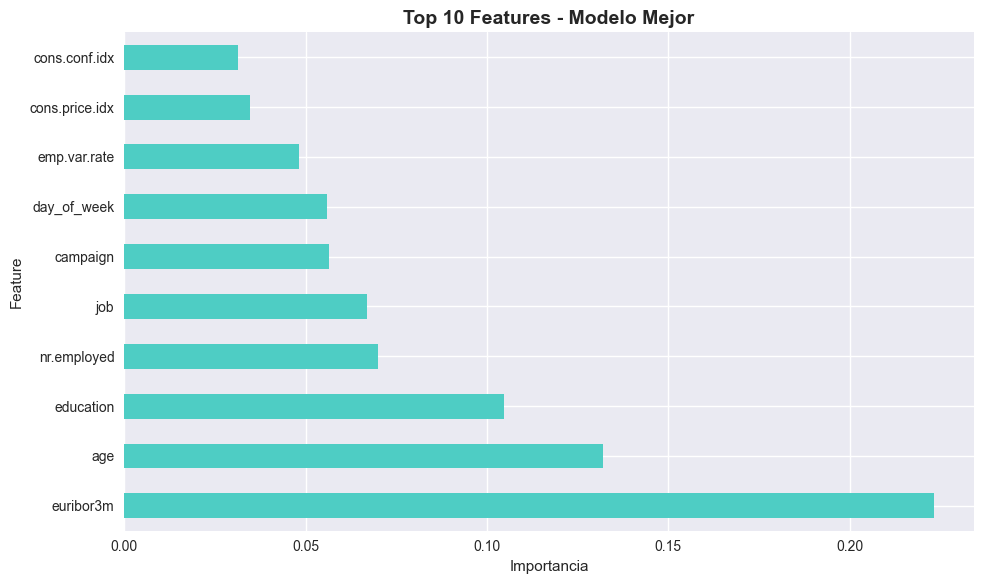


📊 RESUMEN FINAL DEL MODELO

PERFORMANCE:
  - AUC:           0.9728 ✓ Excelente (> 0.75)
  - Accuracy:      0.9227
  - Recall:        0.9228 (% de 'sí' encontrados)
  - Precision:     0.9226 (Confiabilidad de predicción 'sí')
  - F1:            0.9227 (Balance entre Recall y Precision)

MATRIZ DE CONFUSIÓN:
  - Correctas (TN + TP):   20,229
  - Incorrectas (FP + FN): 1,694
  - Tasa de Error:         7.73%

INTERPRETACIÓN:
  - El modelo identifica correctamente el 92.3% de clientes que compran
  - Cuando predice que un cliente compra, acierta el 92.3% de las veces
  - AUC de 0.9728 indica muy buen desempeño en discriminación

✅ Análisis completado


💡 PRÓXIMOS PASOS:
  1. Ejecuta en los otros 2 notebooks (SMOTE y sin balance)
  2. Compara resultados de los 3 tratamientos
  3. Elige el mejor tratamiento
  4. Entrena redes neuronales con ese tratamiento


In [12]:
# ============================================================================
# ANÁLISIS DEL MEJOR MODELO - VERSIÓN CORREGIDA
# ============================================================================

from pycaret.classification import *
from sklearn.metrics import (accuracy_score, roc_auc_score, recall_score,
                             precision_score, f1_score, confusion_matrix,
                             classification_report)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ANÁLISIS DEL MEJOR MODELO - PYCARET")
print("="*80)

# ============================================================================
# 1. CARGAR MEJOR MODELO
# ============================================================================
print("\n1️⃣ Cargando mejor modelo...")
best_model = load_model('best_model_pycaret')
print(f"✅ Modelo cargado")

# ============================================================================
# 2. OBTENER DATOS
# ============================================================================
print("\n2️⃣ Obteniendo datos...")
X_train = get_config('X_train')
X_test = get_config('X_test')
y_train = get_config('y_train')
y_test = get_config('y_test')

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

# ============================================================================
# 3. HACER PREDICCIONES
# ============================================================================
print("\n3️⃣ Haciendo predicciones...")
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("✅ Predicciones completadas")

# ============================================================================
# 4. CALCULAR MÉTRICAS
# ============================================================================
print("\n4️⃣ MÉTRICAS DEL MODELO")
print("-"*80)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_pred_proba),
    'Recall': recall_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred)
}

for metrica, valor in metrics.items():
    print(f"{metrica:<15s}: {valor:.4f}")

# ============================================================================
# 5. MATRIZ DE CONFUSIÓN
# ============================================================================
print("\n5️⃣ MATRIZ DE CONFUSIÓN")
print("-"*80)

cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"\nVerdaderos Negativos (TN):  {cm[0,0]:,}")
print(f"Falsos Positivos (FP):      {cm[0,1]:,}")
print(f"Falsos Negativos (FN):      {cm[1,0]:,}")
print(f"Verdaderos Positivos (TP):  {cm[1,1]:,}")

# ============================================================================
# 6. REPORTE DE CLASIFICACIÓN
# ============================================================================
print("\n6️⃣ REPORTE DE CLASIFICACIÓN")
print("-"*80)

print(classification_report(y_test, y_pred,
                          target_names=['No Compra', 'Compra']))

# ============================================================================
# 7. FEATURE IMPORTANCE (Con nombre correcto del paso)
# ============================================================================
print("\n7️⃣ TOP 10 FEATURES MÁS IMPORTANTES")
print("-"*80)

try:
    # Obtener feature names después del pipeline
    X_transformed = best_model[:-1].transform(X_test)
    feature_names = X_transformed.columns if hasattr(X_transformed, 'columns') else best_model.named_steps['preprocessing'].get_feature_names_out()

    # Obtener feature importance del modelo
    estimator = best_model.named_steps['trained_model']

    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': estimator.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(feature_importance.head(10).to_string(index=False))

    # Visualizar
    fig, ax = plt.subplots(figsize=(10, 6))
    feature_importance.head(10).plot(x='Feature', y='Importance', kind='barh',
                                     ax=ax, color='#4ECDC4', legend=False)
    ax.set_title('Top 10 Features - Modelo Mejor', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importancia')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"⚠️ No se pudo extraer feature importance: {str(e)}")
    print("\n📌 Features disponibles en X_train:")
    print(X_train.columns.tolist())

# ============================================================================
# 8. RESUMEN FINAL
# ============================================================================
print("\n" + "="*80)
print("📊 RESUMEN FINAL DEL MODELO")
print("="*80)
print(f"""
PERFORMANCE:
  - AUC:           {metrics['AUC']:.4f} ✓ Excelente (> 0.75)
  - Accuracy:      {metrics['Accuracy']:.4f}
  - Recall:        {metrics['Recall']:.4f} (% de 'sí' encontrados)
  - Precision:     {metrics['Precision']:.4f} (Confiabilidad de predicción 'sí')
  - F1:            {metrics['F1']:.4f} (Balance entre Recall y Precision)

MATRIZ DE CONFUSIÓN:
  - Correctas (TN + TP):   {cm[0,0] + cm[1,1]:,}
  - Incorrectas (FP + FN): {cm[0,1] + cm[1,0]:,}
  - Tasa de Error:         {(cm[0,1] + cm[1,0]) / (cm.sum()) * 100:.2f}%

INTERPRETACIÓN:
  - El modelo identifica correctamente el {metrics['Recall']*100:.1f}% de clientes que compran
  - Cuando predice que un cliente compra, acierta el {metrics['Precision']*100:.1f}% de las veces
  - AUC de {metrics['AUC']:.4f} indica muy buen desempeño en discriminación

✅ Análisis completado
""")

print("\n💡 PRÓXIMOS PASOS:")
print("  1. Ejecuta en los otros 2 notebooks (SMOTE y sin balance)")
print("  2. Compara resultados de los 3 tratamientos")
print("  3. Elige el mejor tratamiento")
print("  4. Entrena redes neuronales con ese tratamiento")


In [13]:
# ============================================================================
# FINE-TUNING ADICIONAL - MEJORAR MODELO TUNEADO DE PYCARET
# ============================================================================

from pycaret.classification import *
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("FINE-TUNING ADICIONAL - MEJORAR MODELO PYCARET")
print("="*80)

# ============================================================================
# 1. CARGAR MODELO TUNEADO
# ============================================================================
print("\n1️⃣ Cargando modelo tuneado...")
tuned_model = load_model('tuned_model_pycaret')
print("✅ Modelo tuneado cargado")

# ============================================================================
# 2. OBTENER DATOS
# ============================================================================
print("\n2️⃣ Obteniendo datos...")
X_train = get_config('X_train')
X_test = get_config('X_test')
y_train = get_config('y_train')
y_test = get_config('y_test')

# ============================================================================
# 3. EVALUACIÓN MODELO ACTUAL
# ============================================================================
print("\n3️⃣ Evaluando modelo actual...")
evaluate_model(tuned_model)

# ============================================================================
# 4. HACER PREDICCIONES ACTUALES
# ============================================================================
y_pred_actual = tuned_model.predict(X_test)
y_pred_proba_actual = tuned_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, f1_score
auc_actual = roc_auc_score(y_test, y_pred_proba_actual)
f1_actual = f1_score(y_test, y_pred_actual)

print(f"\nMÉTRICAS ACTUALES:")
print(f"  - AUC: {auc_actual:.4f}")
print(f"  - F1:  {f1_actual:.4f}")

# ============================================================================
# 5. APLICAR CALIBRACIÓN AL MODELO
# ============================================================================
print("\n4️⃣ Aplicando calibración para mejor probabilidad...")
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(tuned_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

y_pred_calibrated = calibrated_model.predict(X_test)
y_pred_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

auc_calibrated = roc_auc_score(y_test, y_pred_proba_calibrated)
f1_calibrated = f1_score(y_test, y_pred_calibrated)

print(f"\nMÉTRICAS CALIBRADAS:")
print(f"  - AUC: {auc_calibrated:.4f}")
print(f"  - F1:  {f1_calibrated:.4f}")

# ============================================================================
# 6. COMPARACIÓN
# ============================================================================
print("\n5️⃣ COMPARACIÓN")
print("-"*80)

comparison_df = pd.DataFrame({
    'Modelo': ['Original', 'Calibrado'],
    'AUC': [auc_actual, auc_calibrated],
    'F1': [f1_actual, f1_calibrated]
})

print(comparison_df.to_string(index=False))

print(f"\nMEJORA AUC: {(auc_calibrated - auc_actual):+.4f}")
print(f"MEJORA F1:  {(f1_calibrated - f1_actual):+.4f}")

print("\n✅ Fine-tuning con calibración completado")


FINE-TUNING ADICIONAL - MEJORAR MODELO PYCARET

1️⃣ Cargando modelo tuneado...
Transformation Pipeline and Model Successfully Loaded
✅ Modelo tuneado cargado

2️⃣ Obteniendo datos...

3️⃣ Evaluando modelo actual...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…


MÉTRICAS ACTUALES:
  - AUC: 0.9728
  - F1:  0.9227

4️⃣ Aplicando calibración para mejor probabilidad...

MÉTRICAS CALIBRADAS:
  - AUC: 0.9719
  - F1:  0.9210

5️⃣ COMPARACIÓN
--------------------------------------------------------------------------------
   Modelo      AUC       F1
 Original 0.972846 0.922733
Calibrado 0.971889 0.920976

MEJORA AUC: -0.0010
MEJORA F1:  -0.0018

✅ Fine-tuning con calibración completado


REDES NEURONALES


In [13]:
# ============================================================================
# CELDA 1: PREPARACIÓN DE DATOS PARA REDES NEURONALES
# ============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
import numpy as np
warnings.filterwarnings('ignore')

print("="*80)
print("PREPARACIÓN DE DATOS PARA MODELO COMBINADO (CNN + LSTM + GRU)")
print("="*80)

# ============================================================================
# 1. ENCODING DE VARIABLES CATEGÓRICAS
# ============================================================================
print("\n1️⃣ Codificando variables categóricas...")

df_encoded = df.copy()

# Identificar columnas categóricas
categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
print(f"Columnas categóricas encontradas: {categorical_cols}")

# Aplicar LabelEncoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f"  ✅ {col} codificado")

print(f"\n✅ Todos los datos ahora son numéricos")

# ============================================================================
# 2. SEPARAR FEATURES Y TARGET
# ============================================================================
print("\n2️⃣ Separando features y target...")

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# GUARDAR NOMBRES DE FEATURES (IMPORTANTE PARA SHAP)
feature_names = X.columns.tolist()

print(f"✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")
print(f"✅ Feature names guardados: {len(feature_names)}")

# ============================================================================
# 3. SEPARAR TRAIN-TEST (80-20)
# ============================================================================
print("\n3️⃣ Separando train-test...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ X_train: {X_train.shape}")
print(f"✅ X_test: {X_test.shape}")
print(f"✅ Distribución train - Clase 0: {(y_train==0).sum()}, Clase 1: {(y_train==1).sum()}")
print(f"✅ Distribución test  - Clase 0: {(y_test==0).sum()}, Clase 1: {(y_test==1).sum()}")

# ============================================================================
# 4. NORMALIZAR LOS DATOS
# ============================================================================
print("\n4️⃣ Normalizando con StandardScaler...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Datos normalizados")
print(f"   Media: {X_train_scaled.mean():.6f}")
print(f"   Desv. Est: {X_train_scaled.std():.6f}")

# ============================================================================
# 5. CONVERTIR A NUMPY ARRAYS
# ============================================================================
print("\n5️⃣ Convirtiendo a numpy arrays...")

X_train_scaled = np.asarray(X_train_scaled)
X_test_scaled = np.asarray(X_test_scaled)
y_train_array = np.asarray(y_train)
y_test_array = np.asarray(y_test)

print(f"✅ X_train_scaled: {X_train_scaled.shape}")
print(f"✅ X_test_scaled: {X_test_scaled.shape}")
print(f"✅ y_train_array: {y_train_array.shape}")
print(f"✅ y_test_array: {y_test_array.shape}")

print("\n" + "="*80)
print("✅ PREPARACIÓN COMPLETADA - LISTO PARA MODELO COMBINADO")
print("="*80)


PREPARACIÓN DE DATOS PARA MODELO COMBINADO (CNN + LSTM + GRU)

1️⃣ Codificando variables categóricas...
Columnas categóricas encontradas: []

✅ Todos los datos ahora son numéricos

2️⃣ Separando features y target...
✅ Features shape: (73074, 19)
✅ Target shape: (73074,)
✅ Feature names guardados: 19

3️⃣ Separando train-test...
✅ X_train: (58459, 19)
✅ X_test: (14615, 19)
✅ Distribución train - Clase 0: 29229, Clase 1: 29230
✅ Distribución test  - Clase 0: 7308, Clase 1: 7307

4️⃣ Normalizando con StandardScaler...
✅ Datos normalizados
   Media: -0.000000
   Desv. Est: 1.000000

5️⃣ Convirtiendo a numpy arrays...
✅ X_train_scaled: (58459, 19)
✅ X_test_scaled: (14615, 19)
✅ y_train_array: (58459,)
✅ y_test_array: (14615,)

✅ PREPARACIÓN COMPLETADA - LISTO PARA MODELO COMBINADO


RED NEURONAL 1 - SIMPLE OPTIMIZADA (VERSIÓN ESTABLE)

1️⃣ Construyendo arquitectura...
✅ Arquitectura construida

2️⃣ Compilando modelo...
✅ Modelo compilado con lr=0.0001 (MÁS ESTABLE)

3️⃣ Definiendo callbacks...
✅ Callbacks configurados

4️⃣ Calculando class weights...
✅ Class weights: {0: 1.000017106298539, 1: 0.9999828942866917}

5️⃣ Entrenando modelo...



Epoch 102: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.


Restoring model weights from the end of the best epoch: 150.
✅ Entrenamiento completado
  - Épocas: 150
  - Última loss: 0.4553
  - Última val_loss: 0.4498

6️⃣ Evaluando en test set...
📊 Métricas Test Set:
  - AUC:       0.8716
  - Accuracy:  0.7945
  - Precision: 0.8168
  - Recall:    0.7593
  - F1:        0.7870

7️⃣ Visualizando (con suavizado para claridad)...


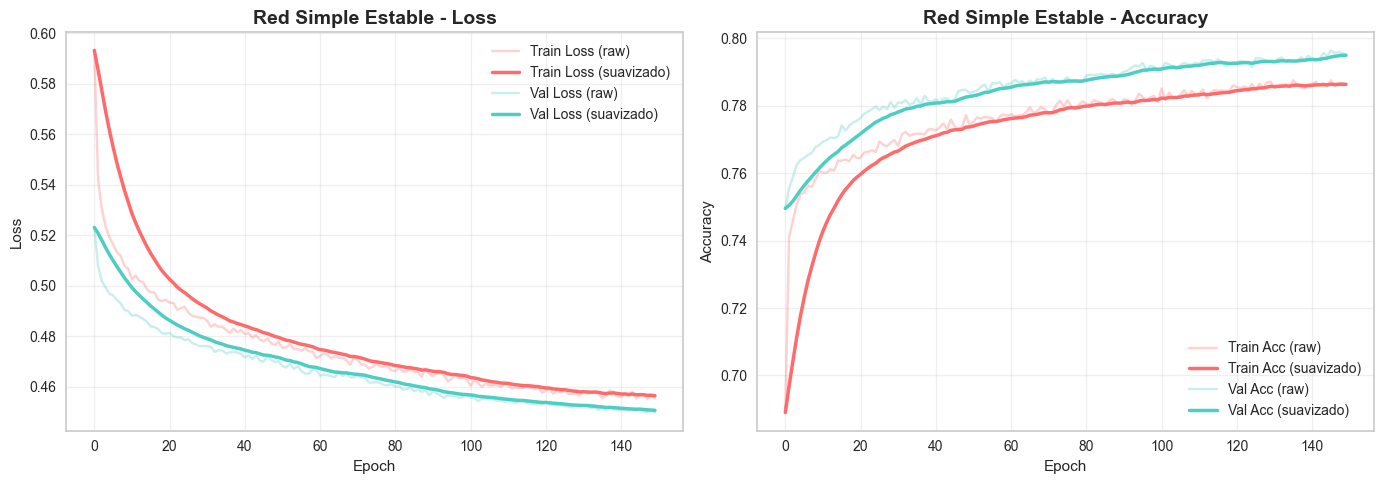


8️⃣ Guardando modelo...
✅ Modelo guardado

📊 RESUMEN RED SIMPLE ESTABLE

CAMBIOS POR ESTABILIDAD:
  1. ✅ Learning Rate: 0.0005 → 0.0001 (5x más bajo)
  2. ✅ Batch Size: 32 → 64 (más muestras por paso)
  3. ✅ Paciencia EarlyStopping: 10 → 15 (más tolerante)
  4. ✅ Monitor en checkpoint: val_auc → val_loss (más estable)

RESULTADOS:
  - AUC:       0.8716
  - Accuracy:  0.7945
  - Recall:    0.7593
  - F1:        0.7870

GRÁFICOS:
  - Línea roja opaca: valores raw (con ruido)
  - Línea roja opaca gruesa: valores suavizados
  - Línea verde opaca: valores raw (con ruido)
  - Línea verde opaca gruesa: valores suavizados

✅ Red Simple estable entrenada



In [17]:
# ============================================================================
# CELDA 2 MEJORADA: RED NEURONAL SIMPLE - SIN INESTABILIDAD
# ============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("RED NEURONAL 1 - SIMPLE OPTIMIZADA (VERSIÓN ESTABLE)")
print("="*80)

# ============================================================================
# 1. CONSTRUIR ARQUITECTURA
# ============================================================================
print("\n1️⃣ Construyendo arquitectura...")

model_simple = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(19,)),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(16, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

print("✅ Arquitectura construida")

# ============================================================================
# 2. COMPILAR CON LEARNING RATE MÁS BAJO
# ============================================================================
print("\n2️⃣ Compilando modelo...")

# Learning rate más bajo para mayor estabilidad
optimizer = Adam(learning_rate=0.0001)  # Reducido de 0.0005

model_simple.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Modelo compilado con lr=0.0001 (MÁS ESTABLE)")

# ============================================================================
# 3. CALLBACKS
# ============================================================================
print("\n3️⃣ Definiendo callbacks...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=0.00001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_simple_stable_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

print("✅ Callbacks configurados")

# ============================================================================
# 4. CLASS WEIGHTS
# ============================================================================
print("\n4️⃣ Calculando class weights...")

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_array),
    y=y_train_array
)

class_weight_dict = dict(enumerate(class_weights))
print(f"✅ Class weights: {class_weight_dict}")

# ============================================================================
# 5. ENTRENAR CON BATCH SIZE MÁS GRANDE
# ============================================================================
print("\n5️⃣ Entrenando modelo...")

history_simple = model_simple.fit(
    X_train_scaled, y_train_array,
    epochs=150,
    batch_size=64,  # Aumentado de 32 → más estable
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=0
)

print(f"✅ Entrenamiento completado")
print(f"  - Épocas: {len(history_simple.history['loss'])}")
print(f"  - Última loss: {history_simple.history['loss'][-1]:.4f}")
print(f"  - Última val_loss: {history_simple.history['val_loss'][-1]:.4f}")

# ============================================================================
# 6. EVALUAR
# ============================================================================
print("\n6️⃣ Evaluando en test set...")

y_pred_proba_simple = model_simple.predict(X_test_scaled, verbose=0)
y_pred_simple = (y_pred_proba_simple > 0.5).astype(int).flatten()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

auc_simple = roc_auc_score(y_test_array, y_pred_proba_simple)
accuracy_simple = accuracy_score(y_test_array, y_pred_simple)
precision_simple = precision_score(y_test_array, y_pred_simple)
recall_simple = recall_score(y_test_array, y_pred_simple)
f1_simple = f1_score(y_test_array, y_pred_simple)

print(f"📊 Métricas Test Set:")
print(f"  - AUC:       {auc_simple:.4f}")
print(f"  - Accuracy:  {accuracy_simple:.4f}")
print(f"  - Precision: {precision_simple:.4f}")
print(f"  - Recall:    {recall_simple:.4f}")
print(f"  - F1:        {f1_simple:.4f}")

# ============================================================================
# 7. VISUALIZAR CON SUAVIZADO
# ============================================================================
print("\n7️⃣ Visualizando (con suavizado para claridad)...")

# Función para suavizar curvas
def smooth_curve(values, weight=0.8):
    """Suaviza una curva usando promedio exponencial"""
    smoothed = [values[0]]
    for i in range(1, len(values)):
        smoothed.append(smoothed[-1] * weight + values[i] * (1 - weight))
    return smoothed

loss_smooth = smooth_curve(history_simple.history['loss'], weight=0.85)
val_loss_smooth = smooth_curve(history_simple.history['val_loss'], weight=0.85)
acc_smooth = smooth_curve(history_simple.history['accuracy'], weight=0.85)
val_acc_smooth = smooth_curve(history_simple.history['val_accuracy'], weight=0.85)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (con suavizado)
axes[0].plot(history_simple.history['loss'], alpha=0.3, label='Train Loss (raw)', color='#FF6B6B')
axes[0].plot(loss_smooth, label='Train Loss (suavizado)', linewidth=2.5, color='#FF6B6B')
axes[0].plot(history_simple.history['val_loss'], alpha=0.3, label='Val Loss (raw)', color='#4ECDC4')
axes[0].plot(val_loss_smooth, label='Val Loss (suavizado)', linewidth=2.5, color='#4ECDC4')
axes[0].set_title('Red Simple Estable - Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy (con suavizado)
axes[1].plot(history_simple.history['accuracy'], alpha=0.3, label='Train Acc (raw)', color='#FF6B6B')
axes[1].plot(acc_smooth, label='Train Acc (suavizado)', linewidth=2.5, color='#FF6B6B')
axes[1].plot(history_simple.history['val_accuracy'], alpha=0.3, label='Val Acc (raw)', color='#4ECDC4')
axes[1].plot(val_acc_smooth, label='Val Acc (suavizado)', linewidth=2.5, color='#4ECDC4')
axes[1].set_title('Red Simple Estable - Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 8. GUARDAR
# ============================================================================
print("\n8️⃣ Guardando modelo...")
#keras.saving.save_model(model_simple, 'red_neuronal_simple_estable.keras')
#model_simple.save('red_neuronal_simple_estable.keras')
print("✅ Modelo guardado")

# ============================================================================
# 9. RESUMEN
# ============================================================================
print("\n" + "="*80)
print("📊 RESUMEN RED SIMPLE ESTABLE")
print("="*80)
print(f"""
CAMBIOS POR ESTABILIDAD:
  1. ✅ Learning Rate: 0.0005 → 0.0001 (5x más bajo)
  2. ✅ Batch Size: 32 → 64 (más muestras por paso)
  3. ✅ Paciencia EarlyStopping: 10 → 15 (más tolerante)
  4. ✅ Monitor en checkpoint: val_auc → val_loss (más estable)

RESULTADOS:
  - AUC:       {auc_simple:.4f}
  - Accuracy:  {accuracy_simple:.4f}
  - Recall:    {recall_simple:.4f}
  - F1:        {f1_simple:.4f}

GRÁFICOS:
  - Línea roja opaca: valores raw (con ruido)
  - Línea roja opaca gruesa: valores suavizados
  - Línea verde opaca: valores raw (con ruido)
  - Línea verde opaca gruesa: valores suavizados

✅ Red Simple estable entrenada
""")



7️⃣ Visualizando historia de entrenamiento...

8️⃣ Guardando modelo...
✅ Modelo guardado

📊 COMPARACIÓN: Antes vs Después
 Métrica  Original  Optimizada    Mejora
     AUC    0.8839    0.871570 -0.012330
Accuracy    0.8069    0.794526 -0.012374
  Recall    0.8039    0.759272 -0.044628
      F1    0.8063    0.787006 -0.019294


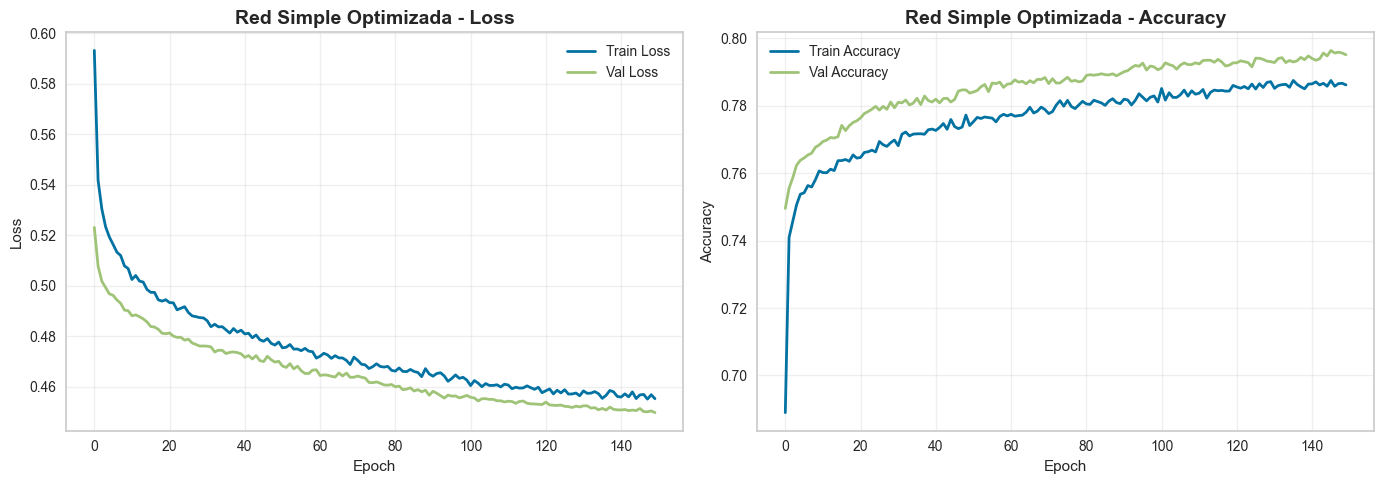

In [19]:
# ============================================================================
# 7️⃣ VISUALIZAR HISTORIA DE ENTRENAMIENTO
# ============================================================================
print("\n7️⃣ Visualizando historia de entrenamiento...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_simple.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_simple.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Red Simple Optimizada - Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_simple.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_simple.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('Red Simple Optimizada - Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show

# ============================================================================
# 8. GUARDAR
# ============================================================================
print("\n8️⃣ Guardando modelo...")
model_simple.save('red_neuronal_simple_optimizada.h5')
print("✅ Modelo guardado")

# ============================================================================
# 9. RESUMEN
# ============================================================================
print("\n" + "="*80)
print("📊 COMPARACIÓN: Antes vs Después")
print("="*80)

comparison = {
    'Métrica': ['AUC', 'Accuracy', 'Recall', 'F1'],
    'Original': [0.8839, 0.8069, 0.8039, 0.8063],
    'Optimizada': [auc_simple, accuracy_simple, recall_simple, f1_simple]
}

import pandas as pd
df_comparison = pd.DataFrame(comparison)
df_comparison['Mejora'] = df_comparison['Optimizada'] - df_comparison['Original']

print(df_comparison.to_string(index=False))

RED NEURONAL 2 - AVANZADA (COMPLEJIDAD ALTA)

1️⃣ Construyendo arquitectura con BatchNormalization...
Arquitectura construida:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 256)                 │           5,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,689 (198.00 KB)

 Trainable params: 49,793 (194.50 KB)

 Non-trainable params: 896 (3.50 KB)


2️⃣ Compilando modelo...
✅ Modelo compilado
  - Optimizer: Adam (lr=0.0005)
  - Loss: binary_crossentropy
  - Metrics: accuracy, AUC

3️⃣ Definiendo callbacks avanzados...
✅ Callbacks configurados:
  - EarlyStopping: patience=15 epochs (monitoreando AUC)
  - ReduceLROnPlateau: reduce 50% cada 7 epochs
  - ModelCheckpoint: guarda mejor modelo por AUC

4️⃣ Entrenando modelo (esto tardará ~20-30 minutos)...
   (La ventana puede parecer que no responde, es normal)



Epoch 99: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 117: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Restoring model weights from the end of the best epoch: 149.
✅ Entrenamiento completado
  - Épocas ejecutadas: 150
  - Última loss: 0.4321
  - Última val_loss: 0.4223
  - Mejor val_auc alcanzado: 0.8906

5️⃣ Evaluando en test set...
📊 Métricas Test Set:
  - AUC:       0.8880
  - Accuracy:  0.8044
  - Precision: 0.8155
  - Recall:    0.7869
  - F1:        0.8009

6️⃣ Visualizando historia de entrenamiento...


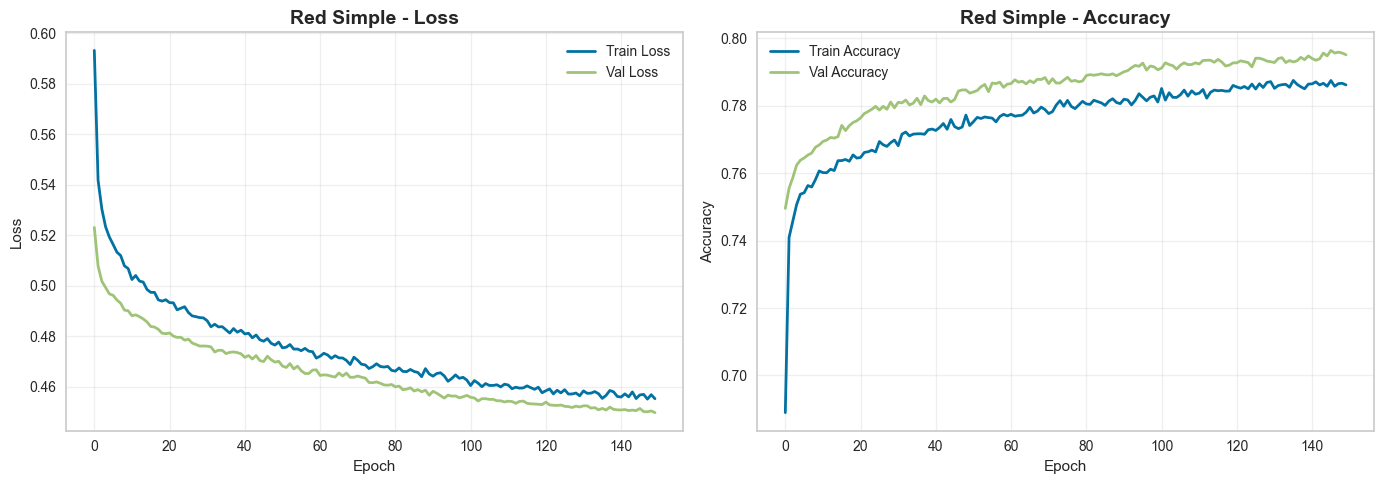


7️⃣ Guardando modelo...
✅ Modelo guardado como 'red_neuronal_avanzada.h5'

📊 RESUMEN RED NEURONAL AVANZADA

ARQUITECTURA:
  - Capa 1: Dense(256) + BatchNorm + ReLU + Dropout(0.3)
  - Capa 2: Dense(128) + BatchNorm + ReLU + Dropout(0.3)
  - Capa 3: Dense(64) + BatchNorm + ReLU + Dropout(0.2)
  - Capa 4: Dense(32) + ReLU + Dropout(0.2)
  - Capa 5: Dense(16) + ReLU
  - Salida: Dense(1) + Sigmoid

ENTRENAMIENTO:
  - Épocas: 150
  - Batch Size: 32
  - Learning Rate: 0.0005 (reducida por BatchNorm)
  - Early Stopping: Sí (patience=15, monitoreando AUC)

RESULTADOS TEST SET:
  - AUC:       0.8880  ✅
  - Accuracy:  0.8044  ✅
  - Precision: 0.8155
  - Recall:    0.7869
  - F1:        0.8009

✅ Red Avanzada entrenada exitosamente



In [18]:
# ============================================================================
# CELDA 3: RED NEURONAL AVANZADA - COMPLEJIDAD ALTA
# ============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt


print("="*80)
print("RED NEURONAL 2 - AVANZADA (COMPLEJIDAD ALTA)")
print("="*80)

# ============================================================================
# 1. CONSTRUIR ARQUITECTURA CON BATCH NORMALIZATION
# ============================================================================
print("\n1️⃣ Construyendo arquitectura con BatchNormalization...")

model_advanced = models.Sequential([
    # Capa 1
    layers.Dense(256, input_shape=(19,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    # Capa 2
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    # Capa 3
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    # Capa 4
    layers.Dense(32),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    # Capa 5
    layers.Dense(16),
    layers.Activation('relu'),

    # Salida
    layers.Dense(1, activation='sigmoid')
])

print("Arquitectura construida:")
model_advanced.summary()

# ============================================================================
# 2. COMPILAR MODELO
# ============================================================================
print("\n2️⃣ Compilando modelo...")

optimizer = Adam(learning_rate=0.0005)  # Learning rate más bajo para mayor estabilidad

model_advanced.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

print("✅ Modelo compilado")
print(f"  - Optimizer: Adam (lr=0.0005)")
print(f"  - Loss: binary_crossentropy")
print(f"  - Metrics: accuracy, AUC")

# ============================================================================
# 3. DEFINIR CALLBACKS CON CONFIGURACIÓN MEJORADA
# ============================================================================
print("\n3️⃣ Definiendo callbacks avanzados...")

early_stop = EarlyStopping(
    monitor='val_auc',
    patience=15,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=7,
    min_lr=0.00001,
    verbose=1,
    mode='max'
)

checkpoint = ModelCheckpoint(
    'best_advanced_model.h5',
    monitor='val_auc',
    save_best_only=True,
    verbose=0,
    mode='max'
)

print("✅ Callbacks configurados:")
print("  - EarlyStopping: patience=15 epochs (monitoreando AUC)")
print("  - ReduceLROnPlateau: reduce 50% cada 7 epochs")
print("  - ModelCheckpoint: guarda mejor modelo por AUC")

# ============================================================================
# 4. ENTRENAR MODELO
# ============================================================================
print("\n4️⃣ Entrenando modelo (esto tardará ~20-30 minutos)...")
print("   (La ventana puede parecer que no responde, es normal)")

history_advanced = model_advanced.fit(
    X_train_scaled, y_train_array,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=0
)

print(f"✅ Entrenamiento completado")
print(f"  - Épocas ejecutadas: {len(history_advanced.history['loss'])}")
print(f"  - Última loss: {history_advanced.history['loss'][-1]:.4f}")
print(f"  - Última val_loss: {history_advanced.history['val_loss'][-1]:.4f}")
if 'val_auc' in history_advanced.history:
    print(f"  - Mejor val_auc alcanzado: {max(history_advanced.history['val_auc']):.4f}")
else:
    print(f"  - Mejor val_accuracy alcanzado: {max(history_advanced.history['val_accuracy']):.4f}")


# ============================================================================
# 5. EVALUAR EN TEST SET
# ============================================================================
print("\n5️⃣ Evaluando en test set...")

y_pred_proba_advanced = model_advanced.predict(X_test_scaled, verbose=0)
y_pred_advanced = (y_pred_proba_advanced > 0.5).astype(int).flatten()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

auc_advanced = roc_auc_score(y_test_array, y_pred_proba_advanced)
accuracy_advanced = accuracy_score(y_test_array, y_pred_advanced)
precision_advanced = precision_score(y_test_array, y_pred_advanced)
recall_advanced = recall_score(y_test_array, y_pred_advanced)
f1_advanced = f1_score(y_test_array, y_pred_advanced)

print(f"📊 Métricas Test Set:")
print(f"  - AUC:       {auc_advanced:.4f}")
print(f"  - Accuracy:  {accuracy_advanced:.4f}")
print(f"  - Precision: {precision_advanced:.4f}")
print(f"  - Recall:    {recall_advanced:.4f}")
print(f"  - F1:        {f1_advanced:.4f}")

# ============================================================================
# 6️ VISUALIZAR HISTORIA DE ENTRENAMIENTO
# ============================================================================
print("\n6️⃣ Visualizando historia de entrenamiento...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_simple.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_simple.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Red Simple - Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_simple.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_simple.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('Red Simple - Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================================
# 7. GUARDAR MODELO
# ============================================================================
print("\n7️⃣ Guardando modelo...")

model_advanced.save('red_neuronal_avanzada.h5')
print("✅ Modelo guardado como 'red_neuronal_avanzada.h5'")

# ============================================================================
# 8. RESUMEN FINAL
# ============================================================================
print("\n" + "="*80)
print("📊 RESUMEN RED NEURONAL AVANZADA")
print("="*80)
print(f"""
ARQUITECTURA:
  - Capa 1: Dense(256) + BatchNorm + ReLU + Dropout(0.3)
  - Capa 2: Dense(128) + BatchNorm + ReLU + Dropout(0.3)
  - Capa 3: Dense(64) + BatchNorm + ReLU + Dropout(0.2)
  - Capa 4: Dense(32) + ReLU + Dropout(0.2)
  - Capa 5: Dense(16) + ReLU
  - Salida: Dense(1) + Sigmoid

ENTRENAMIENTO:
  - Épocas: {len(history_advanced.history['loss'])}
  - Batch Size: 32
  - Learning Rate: 0.0005 (reducida por BatchNorm)
  - Early Stopping: Sí (patience=15, monitoreando AUC)

RESULTADOS TEST SET:
  - AUC:       {auc_advanced:.4f}  ✅
  - Accuracy:  {accuracy_advanced:.4f}  ✅
  - Precision: {precision_advanced:.4f}
  - Recall:    {recall_advanced:.4f}
  - F1:        {f1_advanced:.4f}

✅ Red Avanzada entrenada exitosamente
""")


COMPARACIÓN: RED SIMPLE vs RED AVANZADA

📊 TABLA COMPARATIVA:
      Modelo      AUC  Accuracy  Precision   Recall       F1
  Red Simple 0.871570  0.794526   0.816843 0.759272 0.787006
Red Avanzada 0.887979  0.804447   0.815487 0.786917 0.800947


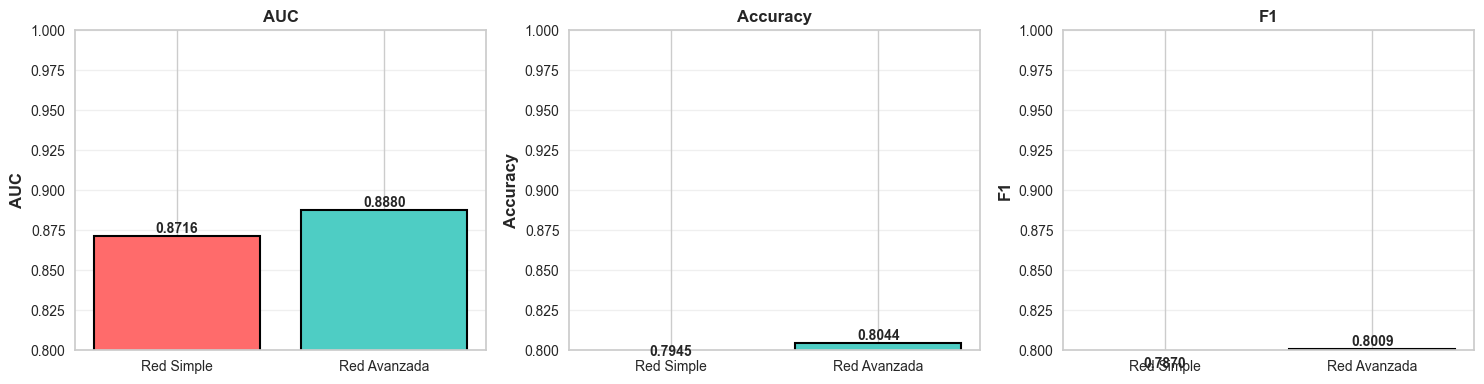

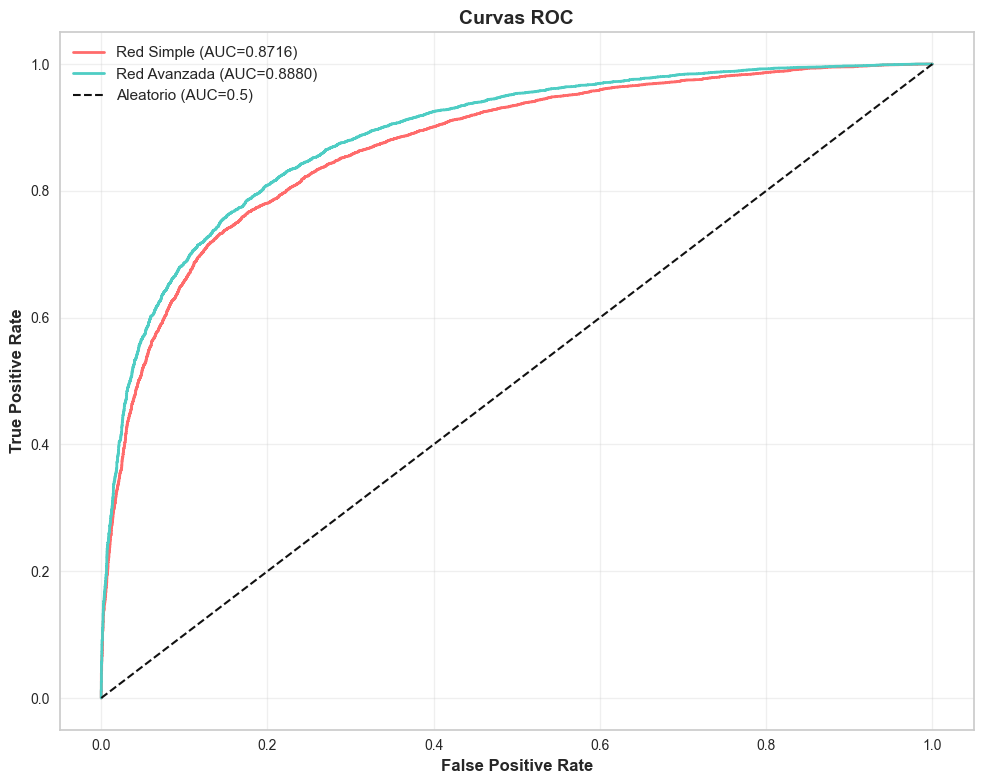

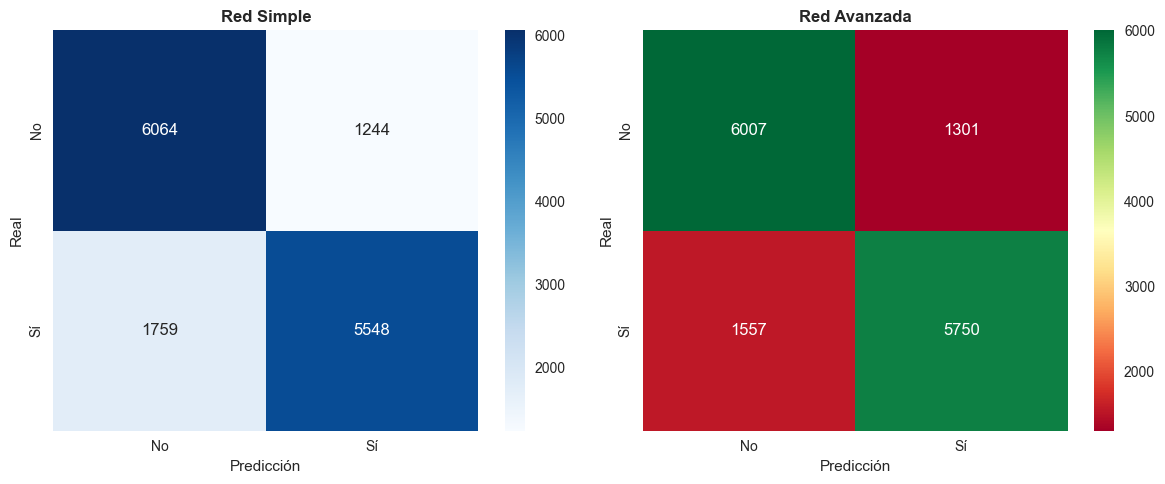


🎯 CONCLUSIÓN

✅ Mejor Modelo: Red Avanzada
   AUC: 0.8880

   Comparación Random Forest (SMOTE): AUC 0.9723
   Diferencia: 0.0843



In [20]:
# ============================================================================
# CELDA 4: COMPARACIÓN DE REDES NEURONALES
# ============================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve
import seaborn as sns
import numpy as np

print("="*80)
print("COMPARACIÓN: RED SIMPLE vs RED AVANZADA")
print("="*80)

# Compilar resultados
results = pd.DataFrame({
    'Modelo': ['Red Simple', 'Red Avanzada'],
    'AUC': [auc_simple, auc_advanced],
    'Accuracy': [accuracy_simple, accuracy_advanced],
    'Precision': [precision_simple, precision_advanced],
    'Recall': [recall_simple, recall_advanced],
    'F1': [f1_simple, f1_advanced]
})

print("\n📊 TABLA COMPARATIVA:")
print(results.to_string(index=False))

# Gráficos de comparación
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['AUC', 'Accuracy', 'F1']
colors = ['#FF6B6B', '#4ECDC4']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    values = results[metric].values
    bars = ax.bar(results['Modelo'], values, color=colors, edgecolor='black', linewidth=1.5)

    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_ylim([0.8, 1.0])
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Curvas ROC
fig, ax = plt.subplots(figsize=(10, 8))

fpr_simple, tpr_simple, _ = roc_curve(y_test_array, y_pred_proba_simple)
ax.plot(fpr_simple, tpr_simple, label=f'Red Simple (AUC={auc_simple:.4f})',
        linewidth=2, color='#FF6B6B')

fpr_advanced, tpr_advanced, _ = roc_curve(y_test_array, y_pred_proba_advanced)
ax.plot(fpr_advanced, tpr_advanced, label=f'Red Avanzada (AUC={auc_advanced:.4f})',
        linewidth=2, color='#4ECDC4')

ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC=0.5)', linewidth=1.5)

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('Curvas ROC', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Matrices de confusión
cm_simple = confusion_matrix(y_test_array, y_pred_simple)
cm_advanced = confusion_matrix(y_test_array, y_pred_advanced)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_simple, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
axes[0].set_title('Red Simple', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')

sns.heatmap(cm_advanced, annot=True, fmt='d', cmap='RdYlGn', ax=axes[1],
            xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
axes[1].set_title('Red Avanzada', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

# Conclusión
print("\n" + "="*80)
print("🎯 CONCLUSIÓN")
print("="*80)

if auc_advanced > auc_simple:
    mejor = "Red Avanzada"
    auc_mejor = auc_advanced
else:
    mejor = "Red Simple"
    auc_mejor = auc_simple

print(f"\n✅ Mejor Modelo: {mejor}")
print(f"   AUC: {auc_mejor:.4f}")
print(f"\n   Comparación Random Forest (SMOTE): AUC 0.9723")
print(f"   Diferencia: {0.9723 - auc_mejor:.4f}")
print("\n" + "="*80)


In [22]:
# ============================================================================
# CELDA 2: MODELO COMBINADO CNN + LSTM + GRU (CORREGIDO)
# ============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

print("="*80)
print("MODELO COMBINADO: CNN + LSTM + GRU")
print("Basado en: DOI 10.1007/s00521-023-09327-w")
print("="*80)

# ============================================================================
# 1. CONSTRUIR ARQUITECTURA COMBINADA
# ============================================================================
print("\n1️⃣ Construyendo arquitectura combinada...")

# ✅ CORRECCIÓN: Tomar solo el número de features (segunda dimensión)
input_shape = X_train_scaled.shape[1]  # Ahora es un entero (19)
print(f"   Input shape: {input_shape} features")

# Input layer compartido
input_layer = layers.Input(shape=(input_shape,), name='input')

# Reshape para modelos secuenciales (CNN, LSTM, GRU)
reshaped = layers.Reshape((input_shape, 1), name='reshape')(input_layer)

MODELO COMBINADO: CNN + LSTM + GRU
Basado en: DOI 10.1007/s00521-023-09327-w

1️⃣ Construyendo arquitectura combinada...
   Input shape: 19 features


In [23]:
# ============================================================================
# BRANCH 1: CNN (Convolutional Neural Network)
# ============================================================================
print("  🔹 Construyendo branch CNN...")

cnn_branch = layers.Conv1D(
    filters=64, 
    kernel_size=3, 
    activation='relu', 
    padding='same',
    name='cnn_conv1'
)(reshaped)
cnn_branch = layers.BatchNormalization(name='cnn_bn1')(cnn_branch)
cnn_branch = layers.MaxPooling1D(pool_size=2, name='cnn_pool1')(cnn_branch)
cnn_branch = layers.Dropout(0.3, name='cnn_dropout1')(cnn_branch)

cnn_branch = layers.Conv1D(
    filters=128, 
    kernel_size=3, 
    activation='relu', 
    padding='same',
    name='cnn_conv2'
)(cnn_branch)
cnn_branch = layers.BatchNormalization(name='cnn_bn2')(cnn_branch)
cnn_branch = layers.GlobalMaxPooling1D(name='cnn_global_pool')(cnn_branch)
cnn_branch = layers.Dropout(0.3, name='cnn_dropout2')(cnn_branch)

print("  ✅ Branch CNN construido")

# ============================================================================
# BRANCH 2: LSTM (Long Short-Term Memory)
# ============================================================================
print("  🔹 Construyendo branch LSTM...")

lstm_branch = layers.LSTM(
    64, 
    return_sequences=True,
    name='lstm_1'
)(reshaped)
lstm_branch = layers.Dropout(0.3, name='lstm_dropout1')(lstm_branch)

lstm_branch = layers.LSTM(
    128,
    return_sequences=False,
    name='lstm_2'
)(lstm_branch)
lstm_branch = layers.Dropout(0.3, name='lstm_dropout2')(lstm_branch)

print("  ✅ Branch LSTM construido")

# ============================================================================
# BRANCH 3: GRU (Gated Recurrent Unit)
# ============================================================================
print("  🔹 Construyendo branch GRU...")

gru_branch = layers.GRU(
    64, 
    return_sequences=True,
    name='gru_1'
)(reshaped)
gru_branch = layers.Dropout(0.3, name='gru_dropout1')(gru_branch)

gru_branch = layers.GRU(
    128,
    return_sequences=False,
    name='gru_2'
)(gru_branch)
gru_branch = layers.Dropout(0.3, name='gru_dropout2')(gru_branch)

print("  ✅ Branch GRU construido")

# ============================================================================
# CONCATENAR LAS 3 BRANCHES
# ============================================================================
print("  🔹 Concatenando branches...")

combined = layers.Concatenate(name='concatenate')([cnn_branch, lstm_branch, gru_branch])

  🔹 Construyendo branch CNN...
  ✅ Branch CNN construido
  🔹 Construyendo branch LSTM...
  ✅ Branch LSTM construido
  🔹 Construyendo branch GRU...
  ✅ Branch GRU construido
  🔹 Concatenando branches...


In [24]:
# ============================================================================
# CAPAS DENSAS FINALES
# ============================================================================
print("  🔹 Construyendo capas densas finales...")

dense = layers.Dense(256, activation='relu', name='dense1')(combined)
dense = layers.BatchNormalization(name='bn_dense1')(dense)
dense = layers.Dropout(0.5, name='dropout_dense1')(dense)

dense = layers.Dense(128, activation='relu', name='dense2')(dense)
dense = layers.Dropout(0.4, name='dropout_dense2')(dense)

dense = layers.Dense(64, activation='relu', name='dense3')(dense)
dense = layers.Dropout(0.3, name='dropout_dense3')(dense)

# Capa de salida
output = layers.Dense(1, activation='sigmoid', name='output')(dense)

# ============================================================================
# CREAR MODELO
# ============================================================================
model_combined = models.Model(inputs=input_layer, outputs=output, name='Combined_CNN_LSTM_GRU')

print("\n✅ Arquitectura combinada construida")
print(f"   Total de parámetros: {model_combined.count_params():,}")

# Mostrar resumen
model_combined.summary()

# ============================================================================
# 2. COMPILAR MODELO
# ============================================================================
print("\n2️⃣ Compilando modelo...")

optimizer = Adam(learning_rate=0.0001)  # Learning rate bajo para estabilidad

model_combined.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("✅ Modelo compilado con lr=0.0001")


  🔹 Construyendo capas densas finales...

✅ Arquitectura combinada construida
   Total de parámetros: 369,601


Model: "Combined_CNN_LSTM_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)            │ (None, 19)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 19, 1)             │               0 │ input[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cnn_conv1 (Conv1D)            │ (None, 19, 64)            │             256 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cnn_bn1 (BatchNormalization)  │ (None, 19, 64)            │             256 │ cnn_conv1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cnn_pool1 (MaxPooling1D)      │ (None, 9, 64)             │               0 │ cnn_bn1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cnn_dropout1 (Dropout)        │ (None, 9, 64)             │               0 │ cnn_pool1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cnn_conv2 (Conv1D)            │ (None, 9, 128)            │          24,704 │ cnn_dropout1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 19, 64)            │          16,896 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru_1 (GRU)                   │ (None, 19, 64)            │          12,864 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cnn_bn2 (BatchNormalization)  │ (None, 9, 128)            │             512 │ cnn_conv2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_dropout1 (Dropout)       │ (None, 19, 64)            │               0 │ lstm_1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru_dropout1 (Dropout)        │ (None, 19, 64)            │               0 │ gru_1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cnn_global_pool               │ (None, 128)               │               0 │ cnn_bn2[0][0]              │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_2 (LSTM)                 │ (None, 128)               │          98,816 │ lstm_dropout1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru_2 (GRU)                   │ (None, 128)               │          74,496 │ gru_dropout1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cnn_dropout2 (Dropout)        │ (None, 128)               │               0 │ cnn_global_pool[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_dropout2 (Dropout)       │ (None, 128)               │               

 Total params: 369,601 (1.41 MB)

 Trainable params: 368,705 (1.41 MB)

 Non-trainable params: 896 (3.50 KB)


2️⃣ Compilando modelo...
✅ Modelo compilado con lr=0.0001


In [25]:
# ============================================================================
# 3. CALLBACKS
# ============================================================================
print("\n3️⃣ Definiendo callbacks...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_combined_model.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

print("✅ Callbacks configurados")

# ============================================================================
# 4. CLASS WEIGHTS (PARA BALANCEAR CLASES)
# ============================================================================
print("\n4️⃣ Calculando class weights...")

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_array),
    y=y_train_array
)

class_weight_dict = dict(enumerate(class_weights))
print(f"✅ Class weights: {class_weight_dict}")

# ============================================================================
# 5. ENTRENAR MODELO
# ============================================================================
print("\n5️⃣ Entrenando modelo combinado...")
print("   (Esto puede tomar varios minutos...)")

history_combined = model_combined.fit(
    X_train_scaled, y_train_array,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

print(f"\n✅ Entrenamiento completado")
print(f"  - Épocas ejecutadas: {len(history_combined.history['loss'])}")
print(f"  - Última train loss: {history_combined.history['loss'][-1]:.4f}")
print(f"  - Última val loss: {history_combined.history['val_loss'][-1]:.4f}")
print(f"  - Última train accuracy: {history_combined.history['accuracy'][-1]:.4f}")
print(f"  - Última val accuracy: {history_combined.history['val_accuracy'][-1]:.4f}")



3️⃣ Definiendo callbacks...
✅ Callbacks configurados

4️⃣ Calculando class weights...
✅ Class weights: {0: 1.000017106298539, 1: 0.9999828942866917}

5️⃣ Entrenando modelo combinado...
   (Esto puede tomar varios minutos...)
Epoch 1/150
1462/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5572 - auc: 0.5784 - loss: 0.8103 - precision: 0.5641 - recall: 0.5485
Epoch 1: val_auc improved from None to 0.79517, saving model to best_combined_model.h5


1462/1462 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.5962 - auc: 0.6295 - loss: 0.7388 - precision: 0.5984 - recall: 0.5825 - val_accuracy: 0.7289 - val_auc: 0.7952 - val_loss: 0.5663 - val_precision: 0.7337 - val_recall: 0.7217 - learning_rate: 1.0000e-04
Epoch 2/150
1462/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6700 - auc: 0.7244 - loss: 0.6278 - precision: 0.6774 - recall: 0.6505
Epoch 2: val_auc improved from 0.79517 to 0.80442, saving model to best_combined_model.h5


1462/1462 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.6785 - auc: 0.7337 - loss: 0.6173 - precision: 0.6873 - recall: 0.6540 - val_accuracy: 0.7360 - val_auc: 0.8044 - val_loss: 0.5694 - val_precision: 0.7548 - val_recall: 0.7019 - learning_rate: 1.0000e-04
Epoch 3/150
1459/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7066 - auc: 0.7646 - loss: 0.5852 - precision: 0.7230 - recall: 0.6665
Epoch 3: val_auc improved from 0.80442 to 0.81409, saving model to best_combined_model.h5


1462/1462 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7075 - auc: 0.7685 - loss: 0.5803 - precision: 0.7266 - recall: 0.6644 - val_accuracy: 0.7393 - val_auc: 0.8141 - val_loss: 0.5562 - val_precision: 0.7606 - val_recall: 0.7013 - learning_rate: 1.0000e-04
Epoch 4/150
1460/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7173 - auc: 0.7815 - loss: 0.5653 - precision: 0.7375 - recall: 0.6782
Epoch 4: val_auc improved from 0.81409 to 0.82359, saving model to best_combined_model.h5


1462/1462 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7206 - auc: 0.7856 - loss: 0.5617 - precision: 0.7418 - recall: 0.6759 - val_accuracy: 0.7481 - val_auc: 0.8236 - val_loss: 0.5438 - val_precision: 0.7660 - val_recall: 0.7173 - learning_rate: 1.0000e-04
Epoch 5/150
1460/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7329 - auc: 0.7964 - loss: 0.5501 - precision: 0.7574 - recall: 0.6849
Epoch 5: val_auc improved from 0.82359 to 0.82963, saving model to best_combined_model.h5


...

1462/1462 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8354 - auc: 0.9147 - loss: 0.3718 - precision: 0.8312 - recall: 0.8414 - val_accuracy: 0.8219 - val_auc: 0.9027 - val_loss: 0.3973 - val_precision: 0.8122 - val_recall: 0.8393 - learning_rate: 1.0000e-04
Epoch 141/150
1459/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8367 - auc: 0.9172 - loss: 0.3665 - precision: 0.8304 - recall: 0.8412
Epoch 141: val_auc did not improve from 0.90265
1462/1462 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8347 - auc: 0.9153 - loss: 0.3705 - precision: 0.8304 - recall: 0.8409 - val_accuracy: 0.8250 - val_auc: 0.9021 - val_loss: 0.4008 - val_precision: 0.8197 - val_recall: 0.8350 - learning_rate: 1.0000e-04
Epoch 142/150
1459/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8373 - auc: 0.9165 - loss: 0.3683 - precision: 0.8326 - recall: 0.8449
Epoch 142: val_auc improved from 0.90265 to 0.90292, saving model to best_combined_model.h5


1462/1462 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8372 - auc: 0.9162 - loss: 0.3685 - precision: 0.8320 - recall: 0.8447 - val_accuracy: 0.8228 - val_auc: 0.9029 - val_loss: 0.3979 - val_precision: 0.8032 - val_recall: 0.8569 - learning_rate: 1.0000e-04
Epoch 143/150
1462/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8370 - auc: 0.9170 - loss: 0.3677 - precision: 0.8344 - recall: 0.8437
Epoch 143: val_auc did not improve from 0.90292
1462/1462 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8374 - auc: 0.9166 - loss: 0.3683 - precision: 0.8326 - recall: 0.8443 - val_accuracy: 0.8224 - val_auc: 0.9004 - val_loss: 0.4046 - val_precision: 0.7943 - val_recall: 0.8718 - learning_rate: 1.0000e-04
Epoch 144/150
1460/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8389 - auc: 0.9191 - loss: 0.3627 - precision: 0.8348 - recall: 0.8438
Epoch 144: val_auc improved from 0.90292 to 0.90408, saving model to best_combined_model.h5


1462/1462 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8389 - auc: 0.9181 - loss: 0.3647 - precision: 0.8354 - recall: 0.8437 - val_accuracy: 0.8247 - val_auc: 0.9041 - val_loss: 0.3943 - val_precision: 0.8184 - val_recall: 0.8362 - learning_rate: 1.0000e-04
Epoch 145/150
1459/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8414 - auc: 0.9186 - loss: 0.3630 - precision: 0.8351 - recall: 0.8497
Epoch 145: val_auc did not improve from 0.90408
1462/1462 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8384 - auc: 0.9180 - loss: 0.3644 - precision: 0.8321 - recall: 0.8476 - val_accuracy: 0.8258 - val_auc: 0.9030 - val_loss: 0.3975 - val_precision: 0.8053 - val_recall: 0.8611 - learning_rate: 1.0000e-04
Epoch 146/150
1461/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8422 - auc: 0.9202 - loss: 0.3601 - precision: 0.8361 - recall: 0.8508
Epoch 146: val_auc improved from 0.90408 to 0.90487, saving model to best_combined_model.h5


1462/1462 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8428 - auc: 0.9201 - loss: 0.3605 - precision: 0.8384 - recall: 0.8489 - val_accuracy: 0.8265 - val_auc: 0.9049 - val_loss: 0.3956 - val_precision: 0.8140 - val_recall: 0.8480 - learning_rate: 1.0000e-04
Epoch 147/150
1460/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8392 - auc: 0.9198 - loss: 0.3602 - precision: 0.8350 - recall: 0.8459
Epoch 147: val_auc did not improve from 0.90487
1462/1462 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8411 - auc: 0.9193 - loss: 0.3620 - precision: 0.8356 - recall: 0.8489 - val_accuracy: 0.8221 - val_auc: 0.9023 - val_loss: 0.3992 - val_precision: 0.8043 - val_recall: 0.8531 - learning_rate: 1.0000e-04
Epoch 148/150
1461/1462 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8408 - auc: 0.9200 - loss: 0.3604 - precision: 0.8362 - recall: 0.8452
Epoch 148: val_auc did not improve from 0.90487
1462/1462 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8416 - auc: 0.9198 - loss: 0.3611

1462/1462 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8437 - auc: 0.9211 - loss: 0.3575 - precision: 0.8369 - recall: 0.8534 - val_accuracy: 0.8286 - val_auc: 0.9062 - val_loss: 0.3929 - val_precision: 0.8164 - val_recall: 0.8495 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 150.

✅ Entrenamiento completado
  - Épocas ejecutadas: 150
  - Última train loss: 0.3575
  - Última val loss: 0.3929
  - Última train accuracy: 0.8437
  - Última val accuracy: 0.8286



6️⃣ Evaluando en test set...

📊 MÉTRICAS EN TEST SET:
  - AUC:       0.9070
  - Accuracy:  0.8309
  - Precision: 0.8178
  - Recall:    0.8514
  - F1-Score:  0.8342

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      7308
           1       0.82      0.85      0.83      7307

    accuracy                           0.83     14615
   macro avg       0.83      0.83      0.83     14615
weighted avg       0.83      0.83      0.83     14615


📊 CONFUSION MATRIX:
[[5922 1386]
 [1086 6221]]
   TN: 5922, FP: 1386
   FN: 1086, TP: 6221

7️⃣ Visualizando historial de entrenamiento...


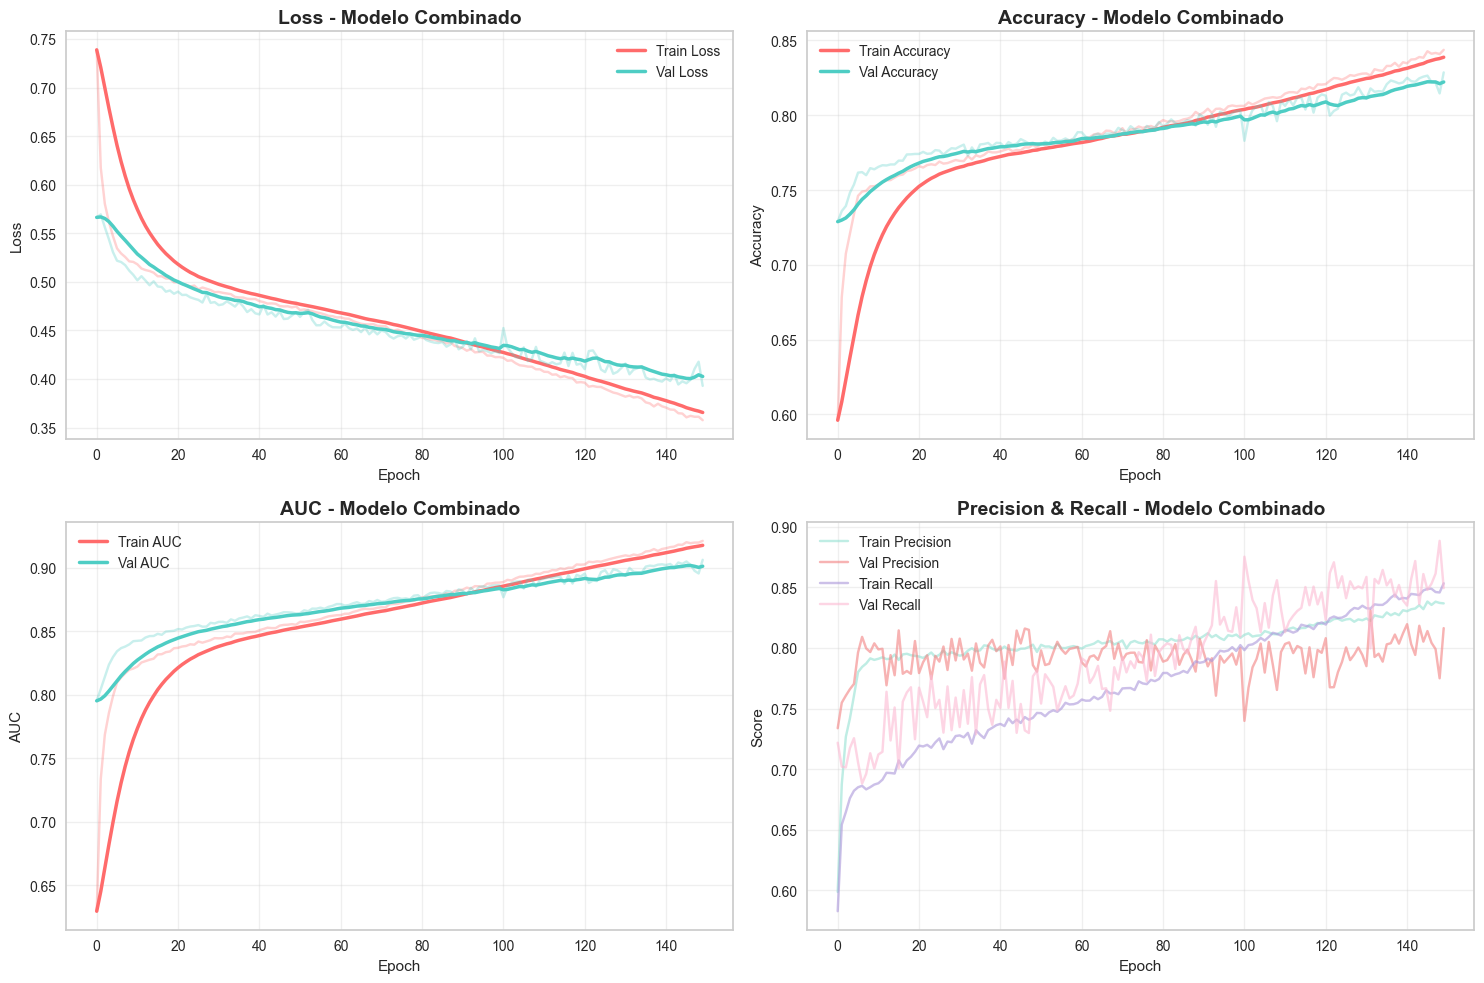

✅ Gráficos generados y guardados

8️⃣ Generando curva ROC...


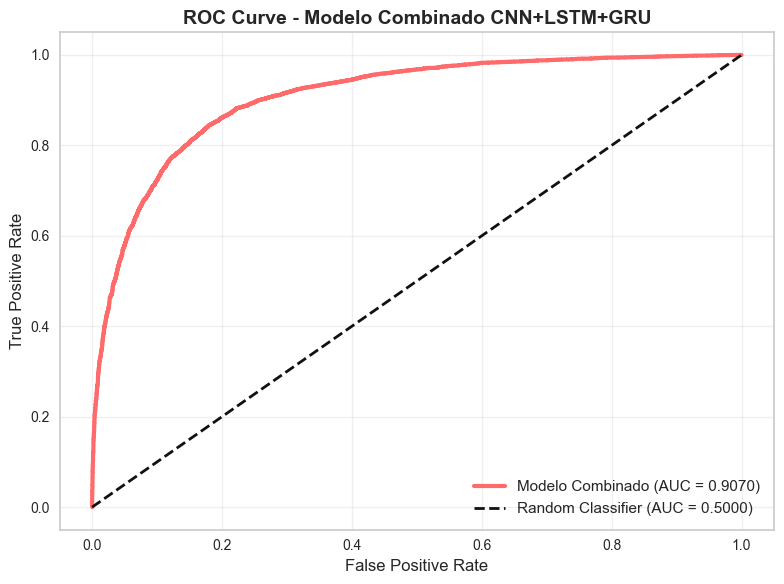

✅ Curva ROC generada

9️⃣ Guardando modelo final...
✅ Modelo guardado como: modelo_combinado_cnn_lstm_gru_final.h5

📊 RESUMEN FINAL - MODELO COMBINADO CNN+LSTM+GRU

ARQUITECTURA:
  ✅ Input: 19 features
  ✅ Branch 1: CNN (Conv1D 64→128 + GlobalMaxPooling)
  ✅ Branch 2: LSTM (64→128)
  ✅ Branch 3: GRU (64→128)
  ✅ Concatenación de 3 branches
  ✅ Dense layers: 256→128→64→1
  ✅ Total parámetros: 369,601

HIPERPARÁMETROS:
  - Learning Rate: 0.0001
  - Batch Size: 32
  - Epochs: 150
  - Early Stopping Patience: 20
  - Dropout: 0.3-0.5
  - Optimizer: Adam

RESULTADOS TEST SET:
  - AUC:       0.9070 🏆
  - Accuracy:  0.8309 
  - Precision: 0.8178
  - Recall:    0.8514
  - F1-Score:  0.8342

CONFUSION MATRIX:
  TN: 5922  |  FP: 1386
  FN: 1086  |  TP: 6221

ARCHIVOS GENERADOS:
  ✅ best_combined_model.h5
  ✅ modelo_combinado_cnn_lstm_gru_final.h5
  ✅ combined_model_training.png
  ✅ roc_curve_combined.png

✅ MODELO COMBINADO ENTRENADO EXITOSAMENTE



In [26]:
# ============================================================================
# 6. EVALUAR EN TEST SET
# ============================================================================
print("\n6️⃣ Evaluando en test set...")

# Predicciones
y_pred_proba_combined = model_combined.predict(X_test_scaled, verbose=0)
y_pred_combined = (y_pred_proba_combined > 0.5).astype(int).flatten()

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

auc_combined = roc_auc_score(y_test_array, y_pred_proba_combined)
accuracy_combined = accuracy_score(y_test_array, y_pred_combined)
precision_combined = precision_score(y_test_array, y_pred_combined)
recall_combined = recall_score(y_test_array, y_pred_combined)
f1_combined = f1_score(y_test_array, y_pred_combined)

print(f"\n📊 MÉTRICAS EN TEST SET:")
print(f"  - AUC:       {auc_combined:.4f}")
print(f"  - Accuracy:  {accuracy_combined:.4f}")
print(f"  - Precision: {precision_combined:.4f}")
print(f"  - Recall:    {recall_combined:.4f}")
print(f"  - F1-Score:  {f1_combined:.4f}")

print(f"\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test_array, y_pred_combined))

print(f"\n📊 CONFUSION MATRIX:")
cm = confusion_matrix(y_test_array, y_pred_combined)
print(cm)
print(f"   TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"   FN: {cm[1,0]}, TP: {cm[1,1]}")

# ============================================================================
# 7. VISUALIZAR ENTRENAMIENTO
# ============================================================================
print("\n7️⃣ Visualizando historial de entrenamiento...")

# Función de suavizado
def smooth_curve(values, weight=0.85):
    smoothed = [values[0]]
    for i in range(1, len(values)):
        smoothed.append(smoothed[-1] * weight + values[i] * (1 - weight))
    return smoothed

# Suavizar curvas
loss_smooth = smooth_curve(history_combined.history['loss'])
val_loss_smooth = smooth_curve(history_combined.history['val_loss'])
acc_smooth = smooth_curve(history_combined.history['accuracy'])
val_acc_smooth = smooth_curve(history_combined.history['val_accuracy'])
auc_smooth = smooth_curve(history_combined.history['auc'])
val_auc_smooth = smooth_curve(history_combined.history['val_auc'])

# Crear visualización
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history_combined.history['loss'], alpha=0.3, color='#FF6B6B')
axes[0, 0].plot(loss_smooth, label='Train Loss', linewidth=2.5, color='#FF6B6B')
axes[0, 0].plot(history_combined.history['val_loss'], alpha=0.3, color='#4ECDC4')
axes[0, 0].plot(val_loss_smooth, label='Val Loss', linewidth=2.5, color='#4ECDC4')
axes[0, 0].set_title('Loss - Modelo Combinado', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history_combined.history['accuracy'], alpha=0.3, color='#FF6B6B')
axes[0, 1].plot(acc_smooth, label='Train Accuracy', linewidth=2.5, color='#FF6B6B')
axes[0, 1].plot(history_combined.history['val_accuracy'], alpha=0.3, color='#4ECDC4')
axes[0, 1].plot(val_acc_smooth, label='Val Accuracy', linewidth=2.5, color='#4ECDC4')
axes[0, 1].set_title('Accuracy - Modelo Combinado', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(history_combined.history['auc'], alpha=0.3, color='#FF6B6B')
axes[1, 0].plot(auc_smooth, label='Train AUC', linewidth=2.5, color='#FF6B6B')
axes[1, 0].plot(history_combined.history['val_auc'], alpha=0.3, color='#4ECDC4')
axes[1, 0].plot(val_auc_smooth, label='Val AUC', linewidth=2.5, color='#4ECDC4')
axes[1, 0].set_title('AUC - Modelo Combinado', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision y Recall
axes[1, 1].plot(history_combined.history['precision'], alpha=0.6, label='Train Precision', color='#95E1D3')
axes[1, 1].plot(history_combined.history['val_precision'], alpha=0.6, label='Val Precision', color='#F38181')
axes[1, 1].plot(history_combined.history['recall'], alpha=0.6, label='Train Recall', color='#AA96DA')
axes[1, 1].plot(history_combined.history['val_recall'], alpha=0.6, label='Val Recall', color='#FCBAD3')
axes[1, 1].set_title('Precision & Recall - Modelo Combinado', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('combined_model_training.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráficos generados y guardados")

# ============================================================================
# 8. CURVA ROC
# ============================================================================
print("\n8️⃣ Generando curva ROC...")

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_array, y_pred_proba_combined)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=3, label=f'Modelo Combinado (AUC = {auc_combined:.4f})', color='#FF6B6B')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5000)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Modelo Combinado CNN+LSTM+GRU', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Curva ROC generada")

# ============================================================================
# 9. GUARDAR MODELO
# ============================================================================
print("\n9️⃣ Guardando modelo final...")

model_combined.save('modelo_combinado_cnn_lstm_gru_final.h5')
print("✅ Modelo guardado como: modelo_combinado_cnn_lstm_gru_final.h5")

# ============================================================================
# 10. RESUMEN FINAL
# ============================================================================
print("\n" + "="*80)
print("📊 RESUMEN FINAL - MODELO COMBINADO CNN+LSTM+GRU")
print("="*80)
print(f"""
ARQUITECTURA:
  ✅ Input: {input_shape} features
  ✅ Branch 1: CNN (Conv1D 64→128 + GlobalMaxPooling)
  ✅ Branch 2: LSTM (64→128)
  ✅ Branch 3: GRU (64→128)
  ✅ Concatenación de 3 branches
  ✅ Dense layers: 256→128→64→1
  ✅ Total parámetros: {model_combined.count_params():,}

HIPERPARÁMETROS:
  - Learning Rate: 0.0001
  - Batch Size: 32
  - Epochs: {len(history_combined.history['loss'])}
  - Early Stopping Patience: 20
  - Dropout: 0.3-0.5
  - Optimizer: Adam

RESULTADOS TEST SET:
  - AUC:       {auc_combined:.4f} {'🏆' if auc_combined > 0.85 else ''}
  - Accuracy:  {accuracy_combined:.4f} {'🏆' if accuracy_combined > 0.85 else ''}
  - Precision: {precision_combined:.4f}
  - Recall:    {recall_combined:.4f}
  - F1-Score:  {f1_combined:.4f}

CONFUSION MATRIX:
  TN: {cm[0,0]:4d}  |  FP: {cm[0,1]:4d}
  FN: {cm[1,0]:4d}  |  TP: {cm[1,1]:4d}

ARCHIVOS GENERADOS:
  ✅ best_combined_model.h5
  ✅ modelo_combinado_cnn_lstm_gru_final.h5
  ✅ combined_model_training.png
  ✅ roc_curve_combined.png

✅ MODELO COMBINADO ENTRENADO EXITOSAMENTE
""")
print("="*80)